In [1]:
import pickle


data0 = pickle.load(open('./tests/decoding_0.pkl', 'rb'))
data0

{'input_ids': tensor([[    1,   529, 29989,  5205, 29989, 29958,    13,  3492,   526,   263,
          19780, 13563,  7451,  1058,  2337, 10049, 29879,   297,   278,  3114,
            310,   263, 21625,   403, 29889,     2, 29871,    13, 29966, 29989,
           1792, 29989, 29958,    13,  5328,   437,   366,  2691,   260,  1540,
            263,  2919,  4086,  1904, 29973,     2, 29871,    13, 29966, 29989,
            465, 22137, 29989, 29958]], device='cuda:0'),
 'past_tokens': [[403, 13, 29958, 13563, 29966, 1540, 29989, 10049],
  None,
  None],
 'token_map': {1: [(529, 29989, 5205)],
  529: [(29989, 5205, 29989)],
  29989: [(5205, 29989, 29958),
   (29958, 13, 3492),
   (1792, 29989, 29958),
   (29958, 13, 5328),
   (465, 22137, 29989)],
  5205: [(29989, 29958, 13)],
  29958: [(13, 3492, 526), (13, 5328, 437)],
  13: [(3492, 526, 263),
   (29966, 29989, 1792),
   (5328, 437, 366),
   (29966, 29989, 465)],
  3492: [(526, 263, 19780)],
  526: [(263, 19780, 13563)],
  263: [(19780, 

In [2]:
data1 = pickle.load(open('./tests/decoding_1.pkl', 'rb'))
len(data1['past_tokens']), len(data1['past_tokens'][0]), len(data1['past_tokens'][1])

/root/work/LookaheadDecoding/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(3, 7, 8)

In [3]:
data2 = pickle.load(open('./tests/decoding_2.pkl', 'rb'))
len(data2['past_tokens']), len(data2['past_tokens'][0]), len(data2['past_tokens'][1]), len(data2['past_tokens'][2])

(3, 6, 7, 7)

In [4]:
data2['token_map']

{1: [(529, 29989, 5205)],
 529: [(29989, 5205, 29989)],
 29989: [(29958, 13, 3492),
  (1792, 29989, 29958),
  (29958, 13, 5328),
  (465, 22137, 29989),
  (29958, 13, 1762)],
 5205: [(29989, 29958, 13)],
 29958: [(13, 3492, 526), (13, 5328, 437)],
 13: [(3492, 526, 263),
  (29966, 29989, 1792),
  (5328, 437, 366),
  (29966, 29989, 465)],
 3492: [(526, 263, 19780)],
 526: [(263, 19780, 13563)],
 263: [(19780, 13563, 7451), (21625, 403, 29889), (2919, 4086, 1904)],
 19780: [(13563, 7451, 1058)],
 13563: [(7451, 1058, 2337)],
 7451: [(1058, 2337, 10049)],
 1058: [(2337, 10049, 29879)],
 2337: [(10049, 29879, 297)],
 10049: [(29879, 297, 278)],
 29879: [(297, 278, 3114)],
 297: [(278, 3114, 310)],
 278: [(3114, 310, 263)],
 3114: [(310, 263, 21625)],
 310: [(263, 21625, 403)],
 21625: [(403, 29889, 2)],
 403: [(29889, 2, 29871)],
 29889: [(2, 29871, 13)],
 2: [(29871, 13, 29966)],
 29871: [(13, 29966, 29989)],
 29966: [(29989, 1792, 29989), (29989, 465, 22137)],
 1792: [(29989, 29958, 13)],

In [5]:
data2['guess_tokens']

In [6]:
data2['outputs'].out_logits.shape, data2['outputs'].inp_logits.shape

(torch.Size([1, 32000]), torch.Size([1, 8, 32000]))

In [7]:
data13 = pickle.load(open('./tests/decoding_13.pkl', 'rb'))
data13['guess_tokens']

In [8]:
data0['past_tokens']

[[403, 13, 29958, 13563, 29966, 1540, 29989, 10049], None, None]

In [21]:
from transformers import AutoModelForCausalLM, AutoTokenizer


model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer

/root/work/LookaheadDecoding/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


LlamaTokenizerFast(name_or_path='TinyLlama/TinyLlama-1.1B-Chat-v1.0', vocab_size=32000, model_max_length=2048, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '</s>'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [22]:
tokenizer.convert_ids_to_tokens(403)

'ate'

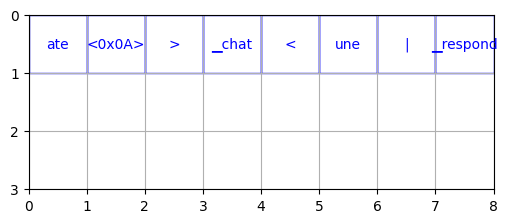

In [23]:
import matplotlib.pyplot as plt
import numpy as np


# Extract the past tokens from data0
past_tokens = data0['past_tokens']

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Add rectangles for each token
for i, row in enumerate(past_tokens):
	if row is not None:
		for j, token in enumerate(row):
			if token is not None:
				rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='b')
				ax.add_patch(rect)
				ax.text(j + 0.5, i + 0.5, tokenizer.convert_ids_to_tokens(token), color='b', ha='center', va='center')

ax.set_xticks(np.arange(0, len(past_tokens[0]) + 1, 1))
ax.set_yticks(np.arange(0, 4, 1))
ax.grid(True)
ax.set_aspect('equal')  # Ensure squares are square-shaped
plt.gca().invert_yaxis()  # Invert y-axis to match typical grid layout
plt.show()


In [28]:
data0['token_map']

{1: [(529, 29989, 5205)],
 529: [(29989, 5205, 29989)],
 29989: [(5205, 29989, 29958),
  (29958, 13, 3492),
  (1792, 29989, 29958),
  (29958, 13, 5328),
  (465, 22137, 29989)],
 5205: [(29989, 29958, 13)],
 29958: [(13, 3492, 526), (13, 5328, 437)],
 13: [(3492, 526, 263),
  (29966, 29989, 1792),
  (5328, 437, 366),
  (29966, 29989, 465)],
 3492: [(526, 263, 19780)],
 526: [(263, 19780, 13563)],
 263: [(19780, 13563, 7451), (21625, 403, 29889), (2919, 4086, 1904)],
 19780: [(13563, 7451, 1058)],
 13563: [(7451, 1058, 2337)],
 7451: [(1058, 2337, 10049)],
 1058: [(2337, 10049, 29879)],
 2337: [(10049, 29879, 297)],
 10049: [(29879, 297, 278)],
 29879: [(297, 278, 3114)],
 297: [(278, 3114, 310)],
 278: [(3114, 310, 263)],
 3114: [(310, 263, 21625)],
 310: [(263, 21625, 403)],
 21625: [(403, 29889, 2)],
 403: [(29889, 2, 29871)],
 29889: [(2, 29871, 13)],
 2: [(29871, 13, 29966)],
 29871: [(13, 29966, 29989)],
 29966: [(29989, 1792, 29989), (29989, 465, 22137)],
 1792: [(29989, 29958, 13

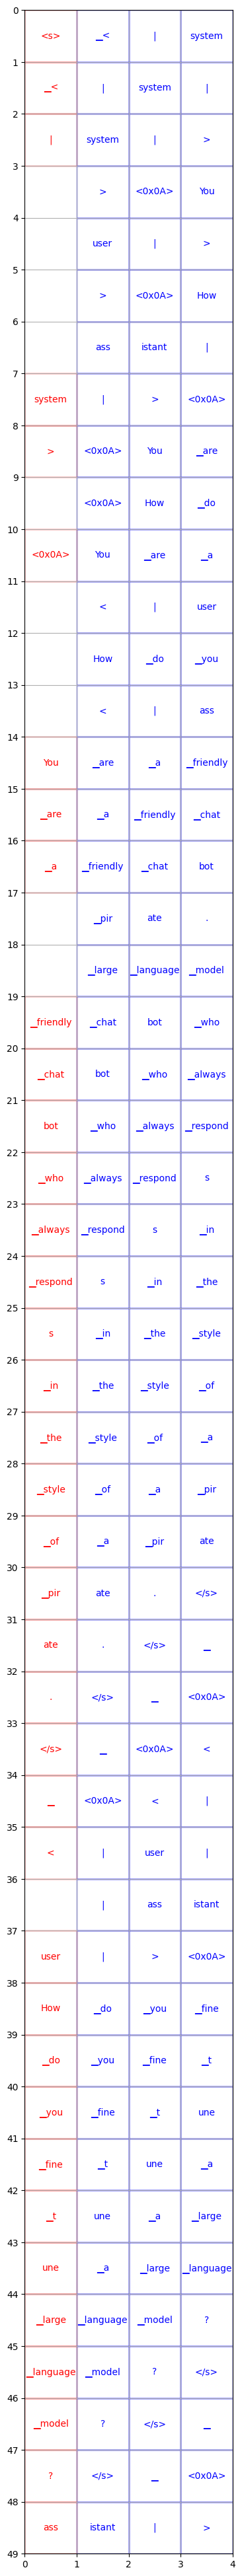

In [38]:
token_map = data0['token_map']


# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 50))

row = 0
for k, grams in token_map.items():
	key_token = tokenizer.convert_ids_to_tokens(k)
	for i, gram in enumerate(grams):
		if i == 0:
			rect = plt.Rectangle((0, row), 1, 1, fill=False, edgecolor='r')
			ax.add_patch(rect)
			ax.text(0.5, row + 0.5, key_token, color='r', ha='center', va='center')
			#ax.text(0.5, row + 0.5, k, color='r', ha='center', va='center')
		for j, token in enumerate(gram):
			rect = plt.Rectangle((1 + j, row), 1, 1, fill=False, edgecolor='b')
			ax.add_patch(rect)
			ax.text(1 + j + 0.5, row + 0.5, tokenizer.convert_ids_to_tokens(token), color='b', ha='center', va='center')

		row += 1

ax.set_xticks(np.arange(0, 5, 1))
ax.set_yticks(np.arange(0, row + 1, 1))
ax.grid(True)
ax.set_aspect('equal')  # Ensure squares are square-shaped
plt.gca().invert_yaxis()  # Invert y-axis to match typical grid layout
plt.show()


In [39]:
data0['input_ids'], data1['input_ids'], data2['input_ids']

(tensor([[    1,   529, 29989,  5205, 29989, 29958,    13,  3492,   526,   263,
          19780, 13563,  7451,  1058,  2337, 10049, 29879,   297,   278,  3114,
            310,   263, 21625,   403, 29889,     2, 29871,    13, 29966, 29989,
           1792, 29989, 29958,    13,  5328,   437,   366,  2691,   260,  1540,
            263,  2919,  4086,  1904, 29973,     2, 29871,    13, 29966, 29989,
            465, 22137, 29989, 29958]], device='cuda:0'),
 tensor([[    1,   529, 29989,  5205, 29989, 29958,    13,  3492,   526,   263,
          19780, 13563,  7451,  1058,  2337, 10049, 29879,   297,   278,  3114,
            310,   263, 21625,   403, 29889,     2, 29871,    13, 29966, 29989,
           1792, 29989, 29958,    13,  5328,   437,   366,  2691,   260,  1540,
            263,  2919,  4086,  1904, 29973,     2, 29871,    13, 29966, 29989,
            465, 22137, 29989, 29958,    13]], device='cuda:0'),
 tensor([[    1,   529, 29989,  5205, 29989, 29958,    13,  3492,   526,   26

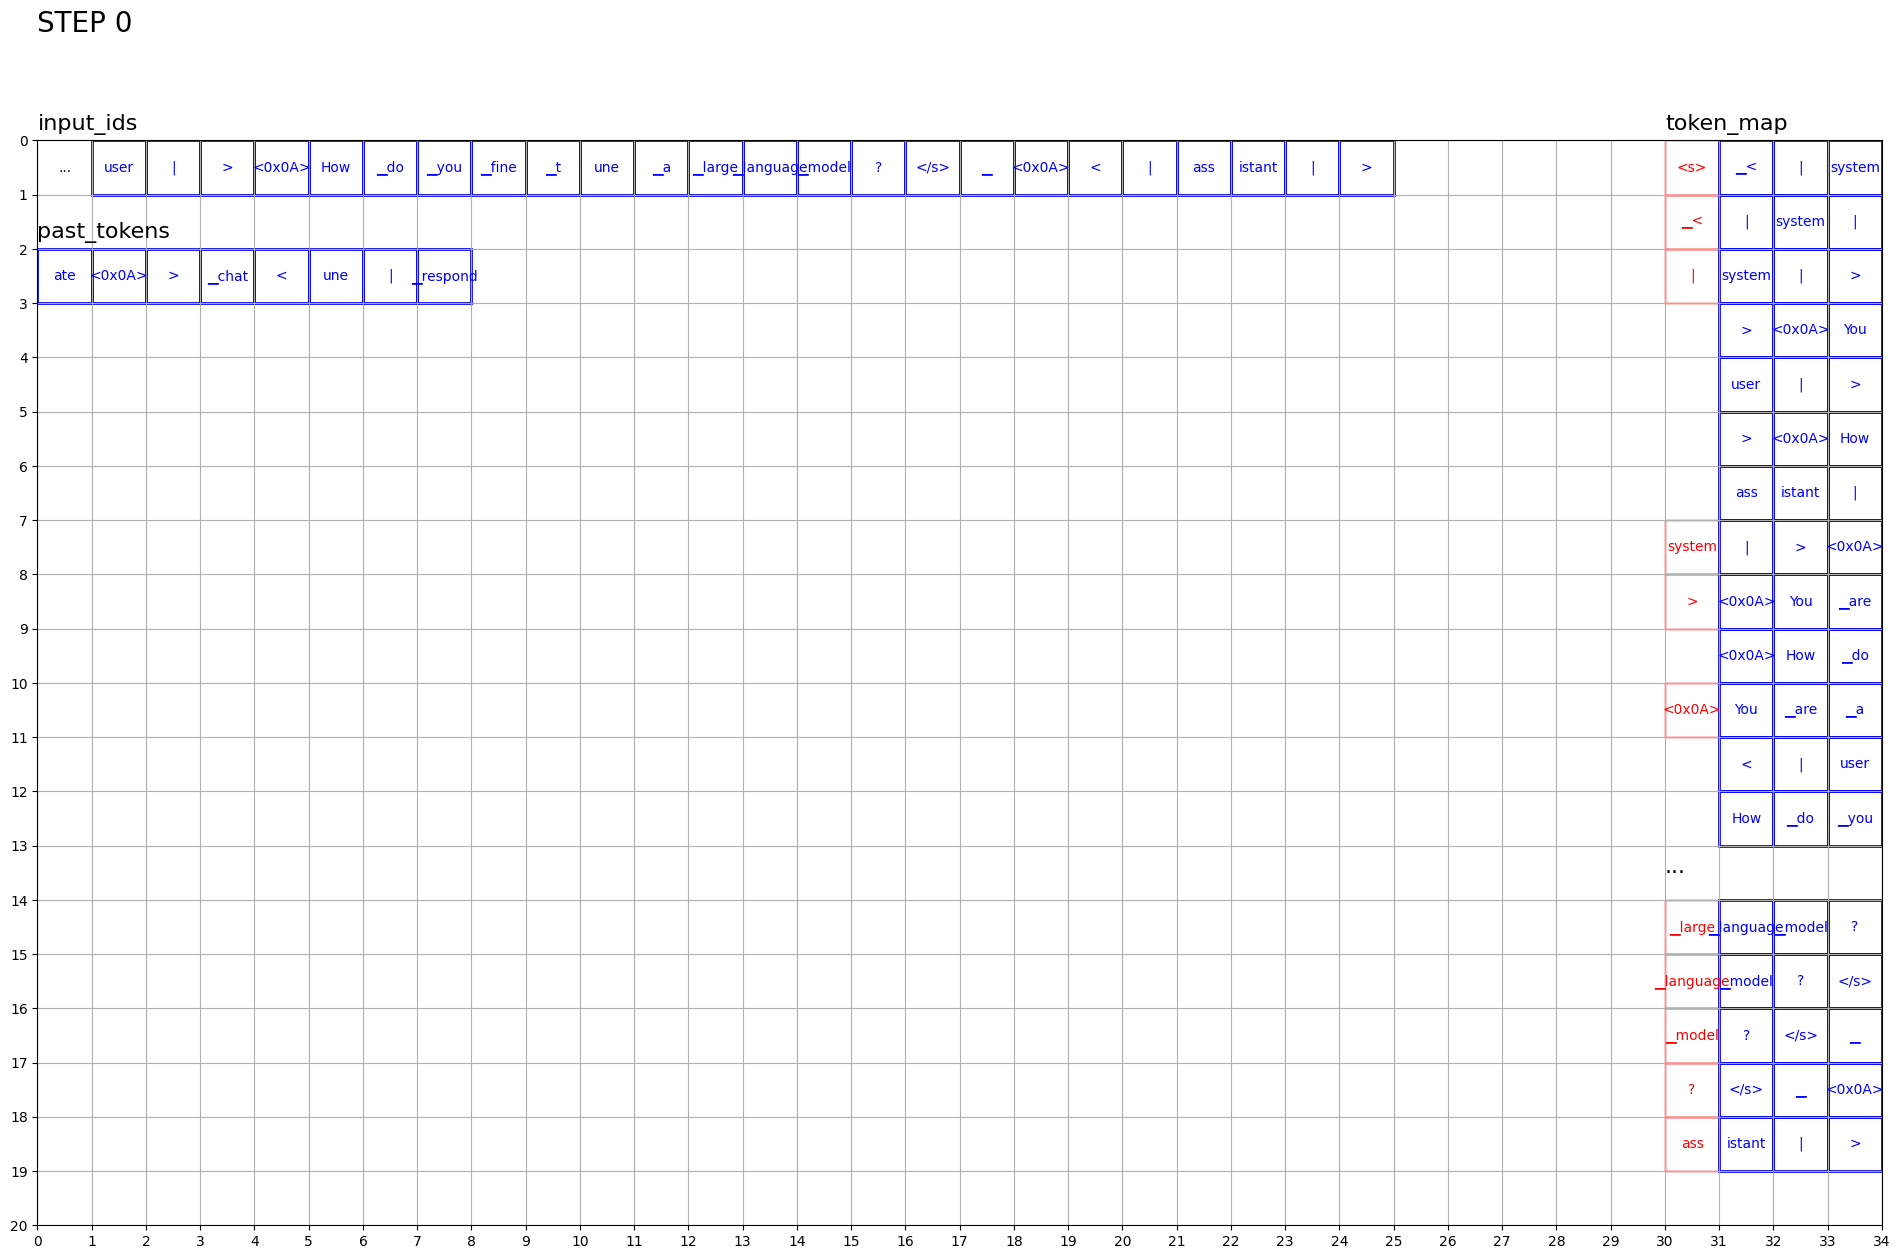

In [109]:

def plot_frame (data, index):
	fig, ax = plt.subplots(figsize=(34 * 0.7, 22 * 0.7))

	ax.text(0, -2, f'STEP {index}', color='black', fontsize=20)

	# plot input_ids
	ax.text(0, -0.2, 'input_ids', color='black', fontsize=16)
	ax.text(0.5, 0.5, '...', color='black', ha='center', va='center')
	input_ids = data['input_ids'][0, -24:].tolist()
	for i, token in enumerate(input_ids):
		rect = plt.Rectangle((1 + i, 0), 1, 1, fill=False, edgecolor='b', linewidth=2)
		ax.add_patch(rect)
		ax.text(1 + i + 0.5, 0.5, tokenizer.convert_ids_to_tokens(token), color='b', ha='center', va='center')

	# plot past tokens
	ax.text(0, 1.8, 'past_tokens', color='black', fontsize=16)

	past_tokens = data['past_tokens']
	for i, row in enumerate(past_tokens):
		if row is not None:
			for j, token in enumerate(row):
				if token is not None:
					rect = plt.Rectangle((j, 2 + i), 1, 1, fill=False, edgecolor='b', linewidth=2)
					ax.add_patch(rect)
					ax.text(j + 0.5, 2 + i + 0.5, tokenizer.convert_ids_to_tokens(token), color='b', ha='center', va='center')

	# plot token_map
	ax.text(30, -0.2, 'token_map', color='black', fontsize=16)

	token_map = data['token_map']
	row = 0
	at_tail = False
	tail_keys = list(token_map.keys())[-5:]
	for k, grams in token_map.items():
		if row > 12 and not (k in tail_keys):
			continue

		key_token = tokenizer.convert_ids_to_tokens(k)
		for i, gram in enumerate(grams):
			if i == 0:
				rect = plt.Rectangle((30, row), 1, 1, fill=False, edgecolor='r')
				ax.add_patch(rect)
				ax.text(30.5, row + 0.5, key_token, color='r', ha='center', va='center')
			for j, token in enumerate(gram):
				rect = plt.Rectangle((31 + j, row), 1, 1, fill=False, edgecolor='b', linewidth=2)
				ax.add_patch(rect)
				ax.text(31 + j + 0.5, row + 0.5, tokenizer.convert_ids_to_tokens(token), color='b', ha='center', va='center')

			row += 1
			if not at_tail and row > 12:
				break

		if not at_tail and row > 12:
			at_tail = True
			ax.text(30, row + 0.5, '...', color='black', fontsize=16)
			row += 1

	# plot guess_tokens
	ax.text(0, 5.8, 'guess_tokens', color='black', fontsize=16)
	guess_tokens = data['guess_tokens']
	if guess_tokens is not None:
		for i, token in enumerate(guess_tokens):
			rect = plt.Rectangle((i, 6), 1, 1, fill=False, edgecolor='b', linewidth=2)
			ax.add_patch(rect)
			ax.text(i + 0.5, 6 + 0.5, tokenizer.convert_ids_to_tokens(token), color='b', ha='center', va='center')

	ax.set_xticks(np.arange(0, 34 + 1, 1))
	ax.set_yticks(np.arange(0, 21, 1))
	ax.grid(True)
	ax.set_aspect('equal')  # Ensure squares are square-shaped
	plt.gca().invert_yaxis()  # Invert y-axis to match typical grid layout
	plt.savefig(f'./tests/plot_{index}.png')

plot_frame(data0, 0)


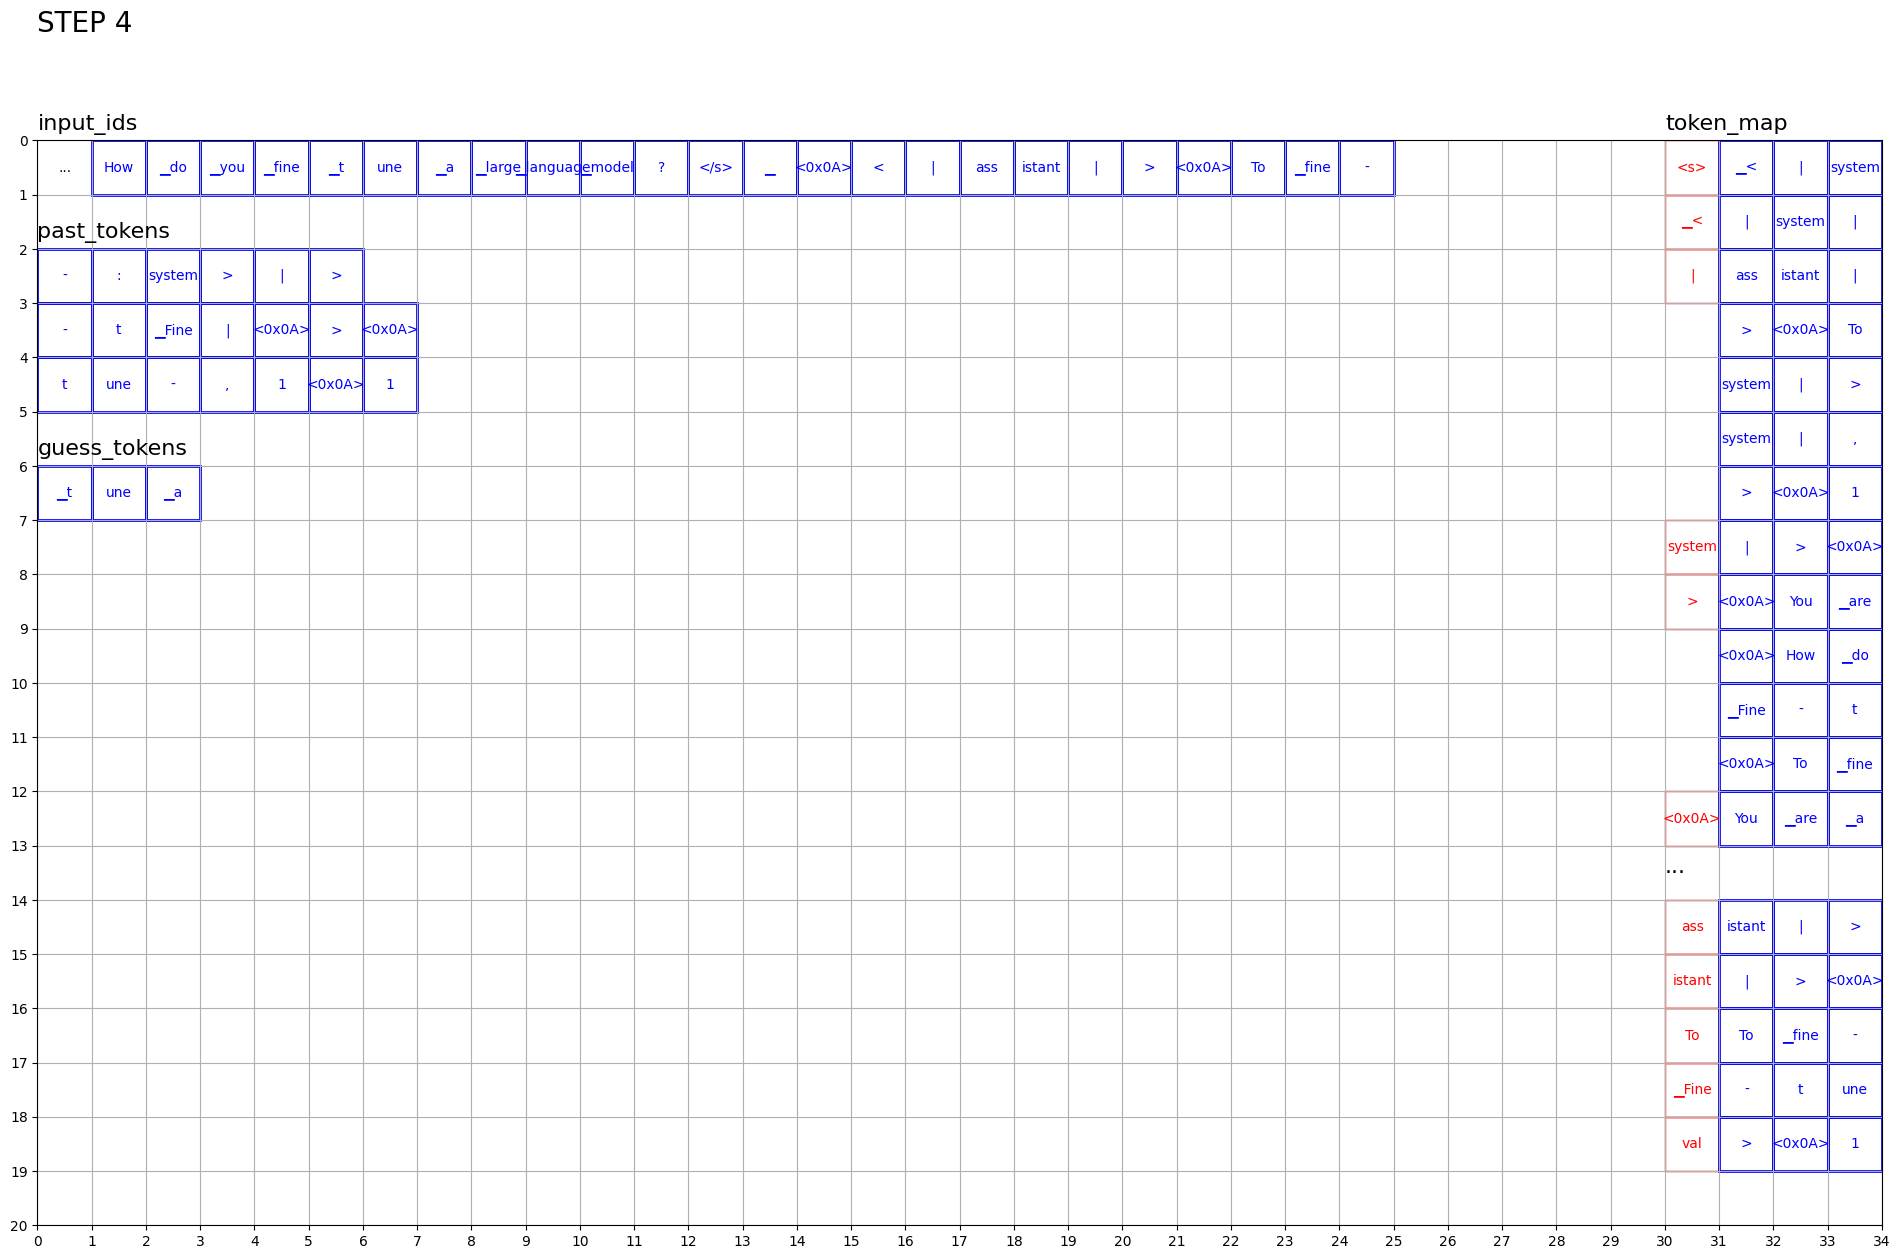

In [110]:
data4 = pickle.load(open('./tests/decoding_4.pkl', 'rb'))
plot_frame(data4, 4)

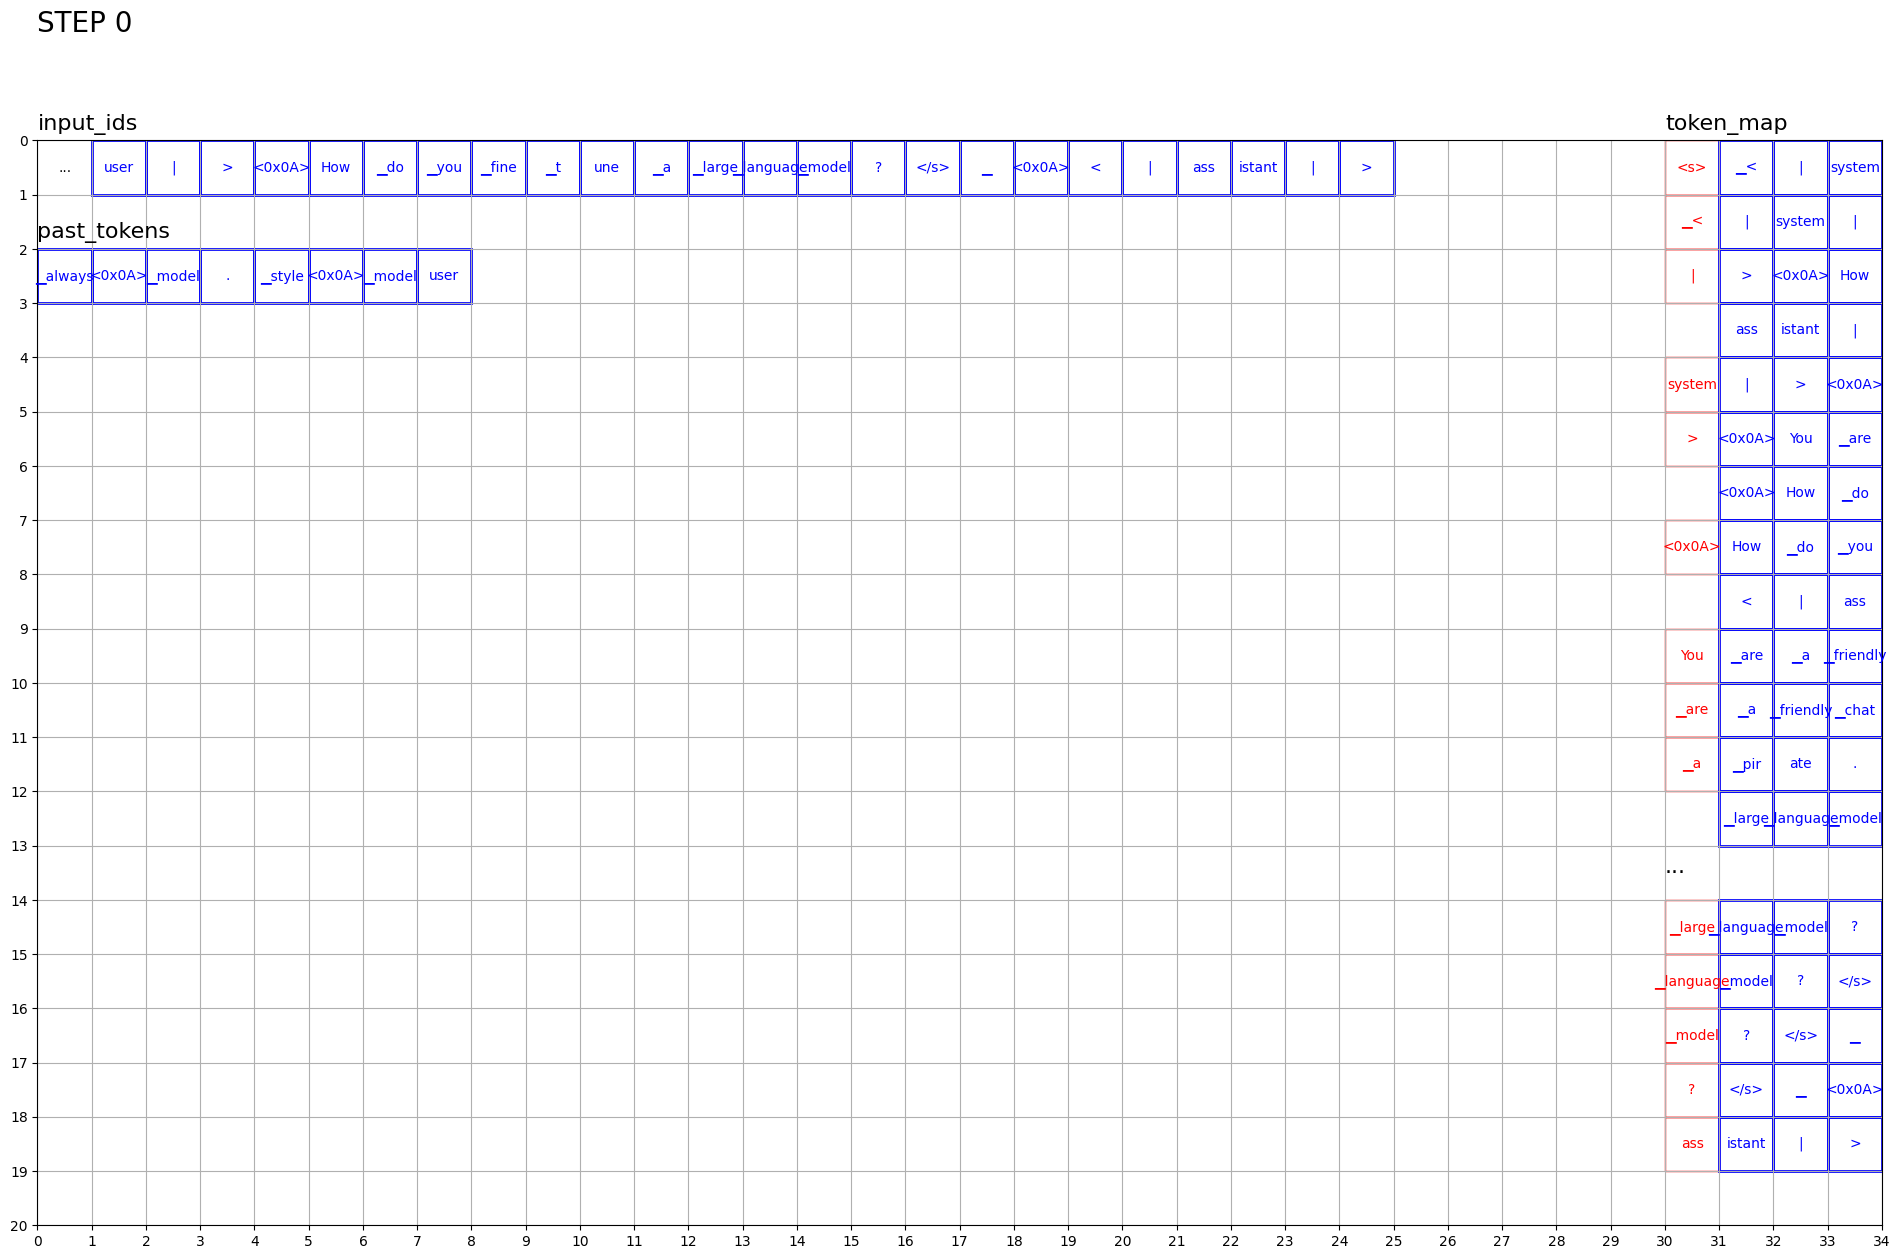

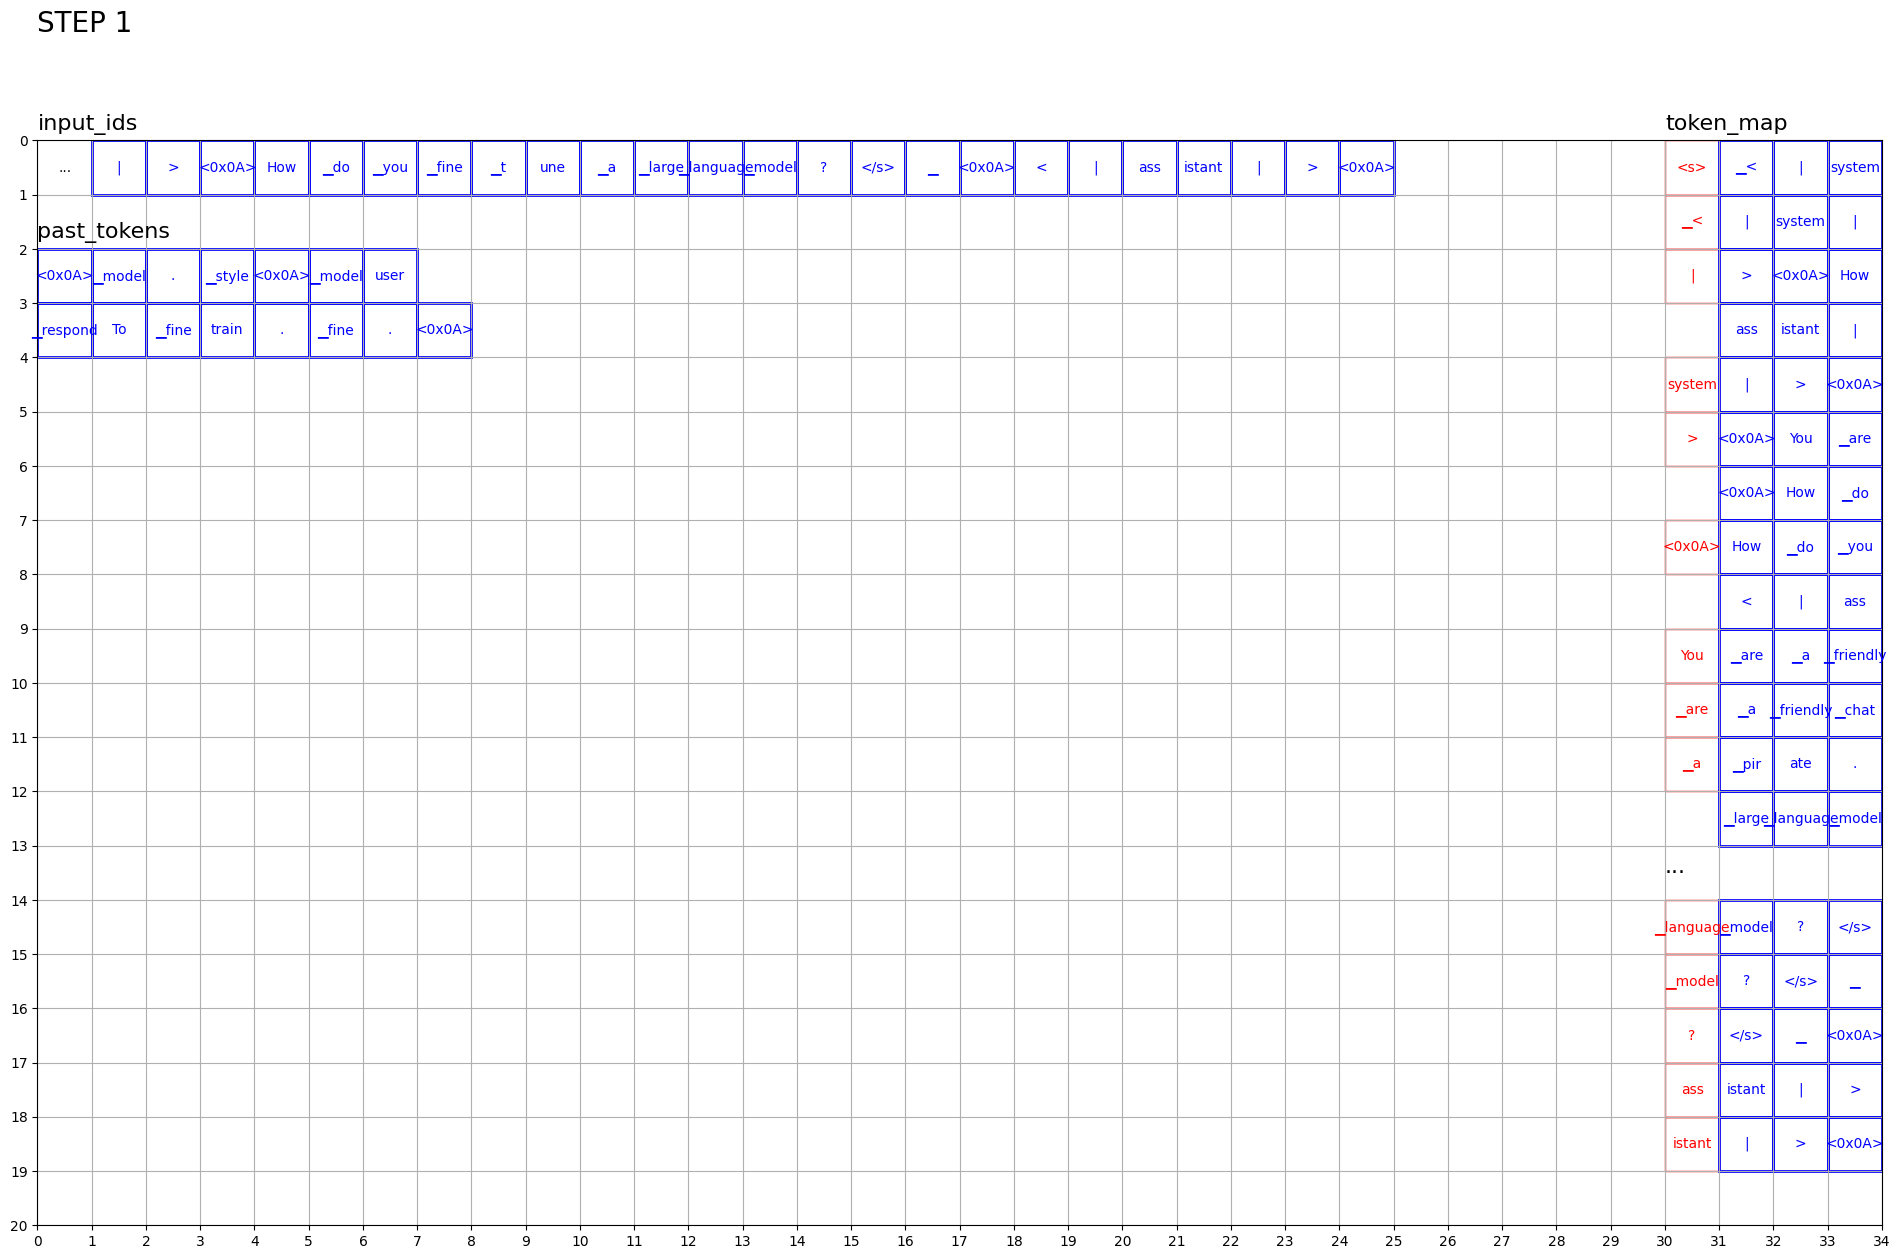

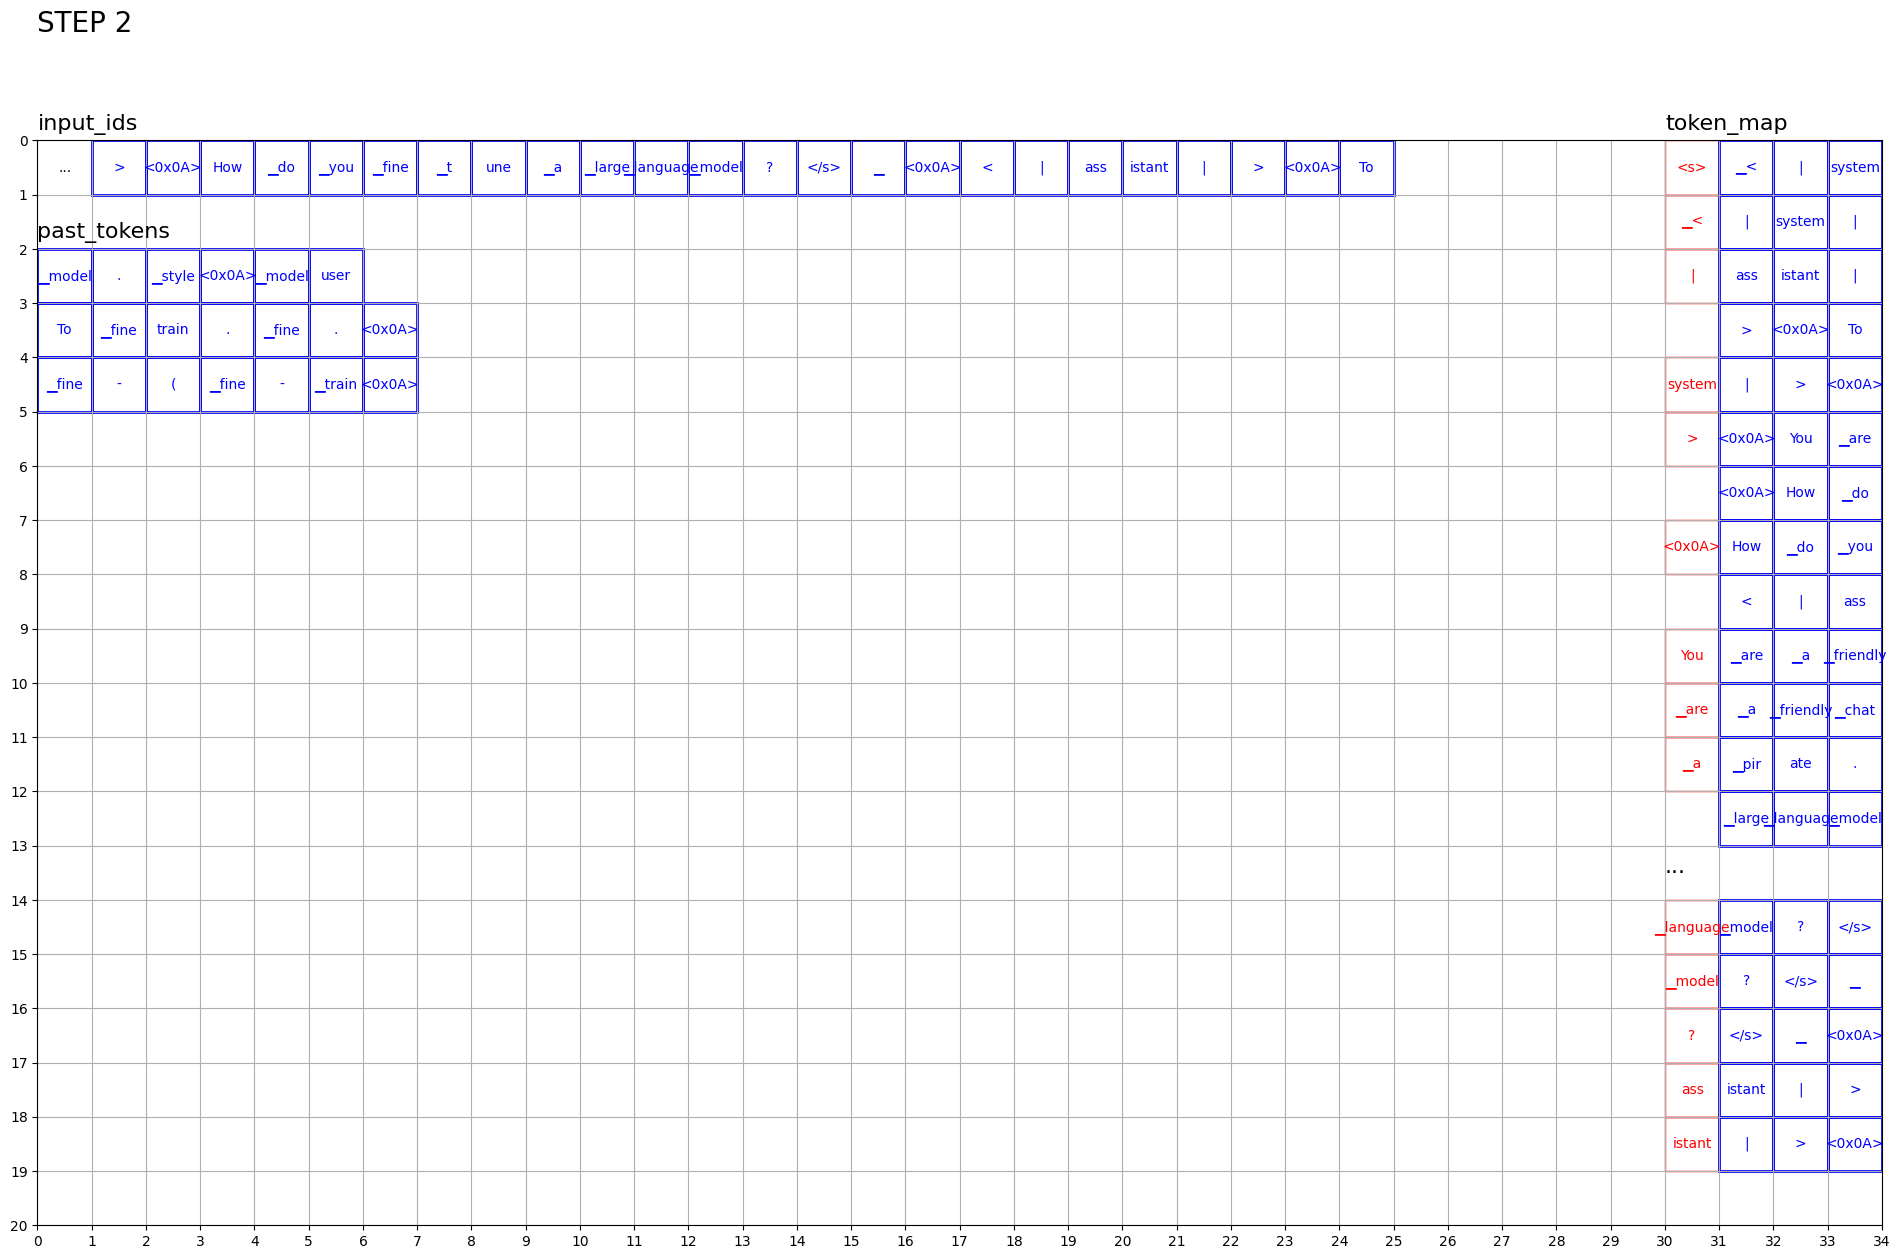

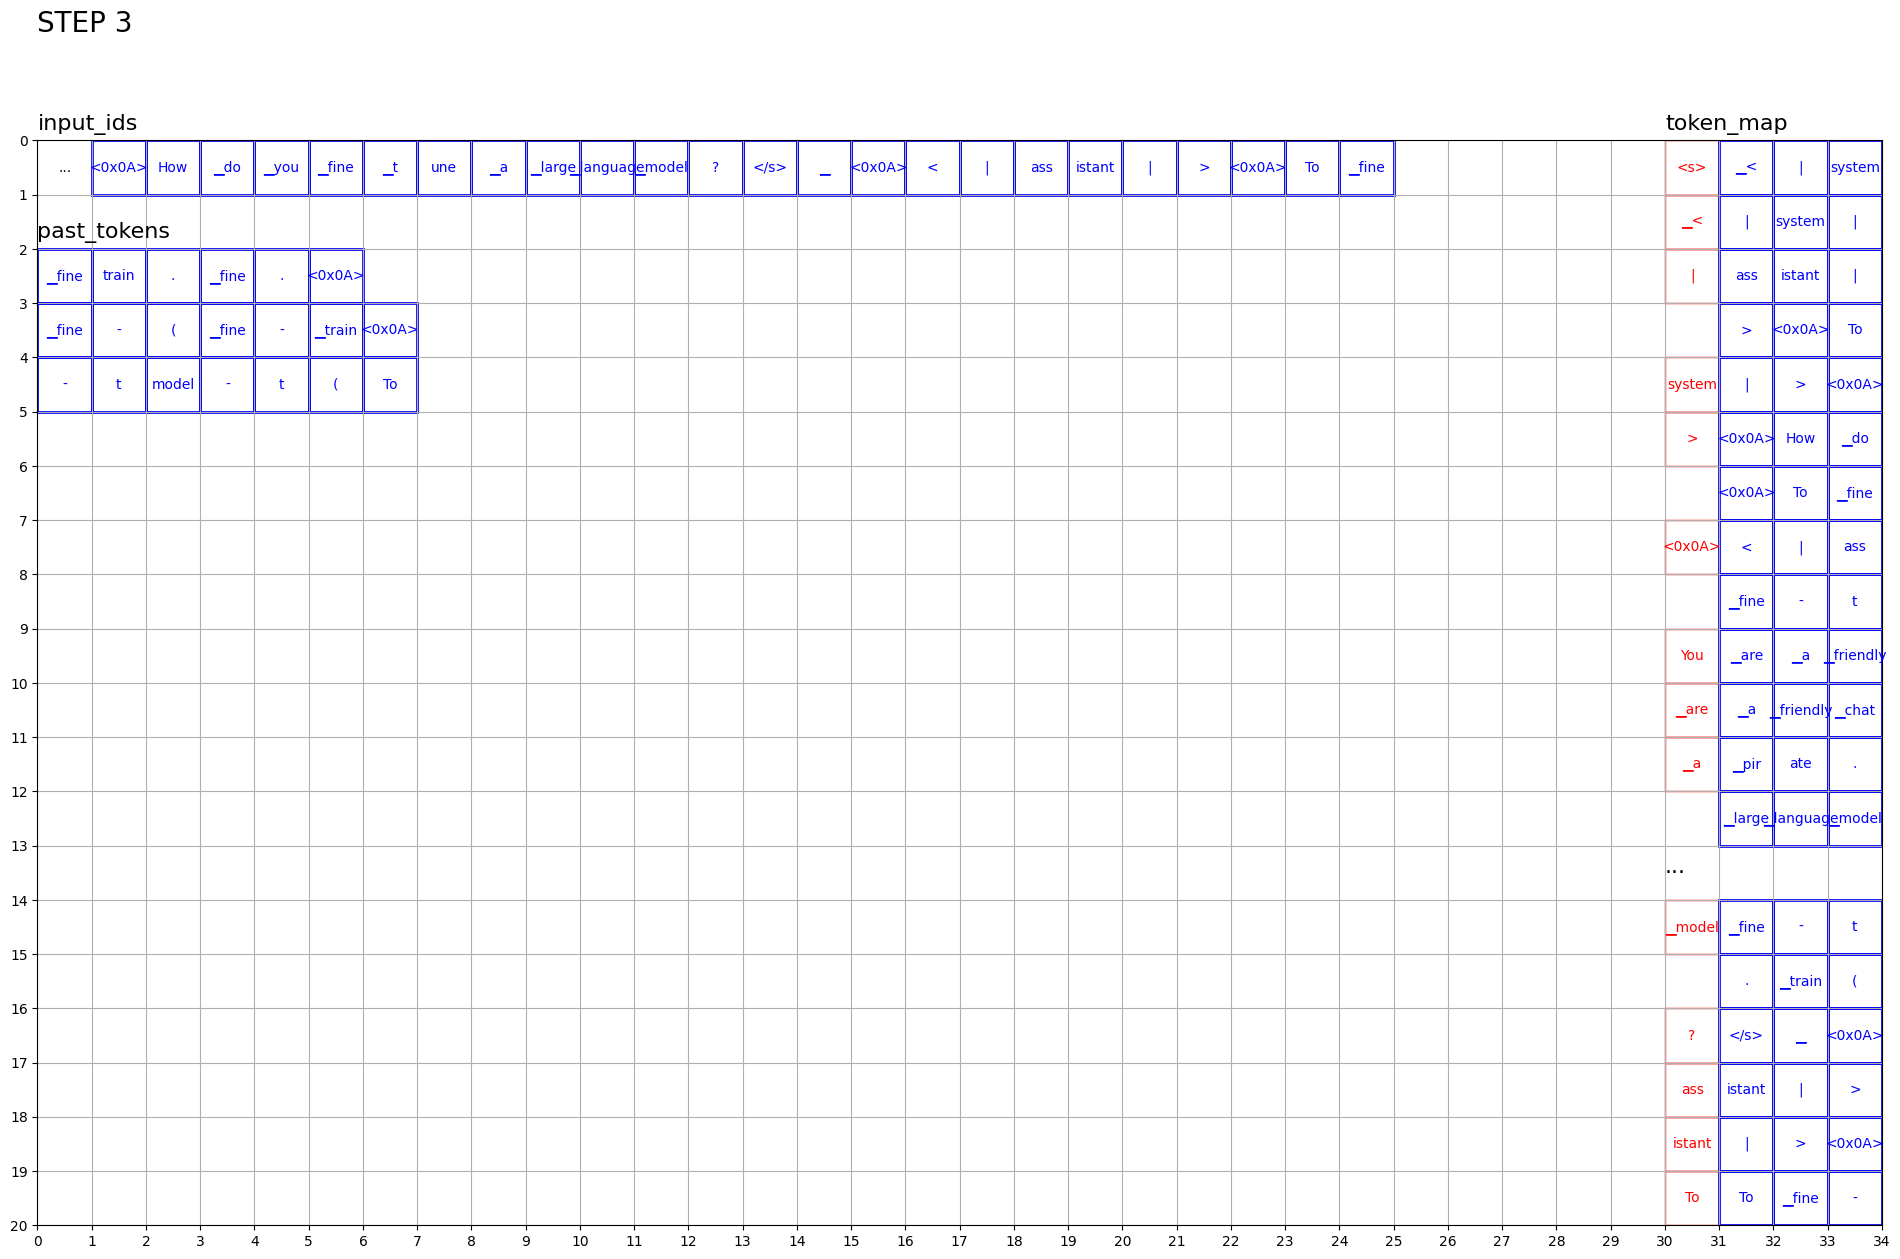

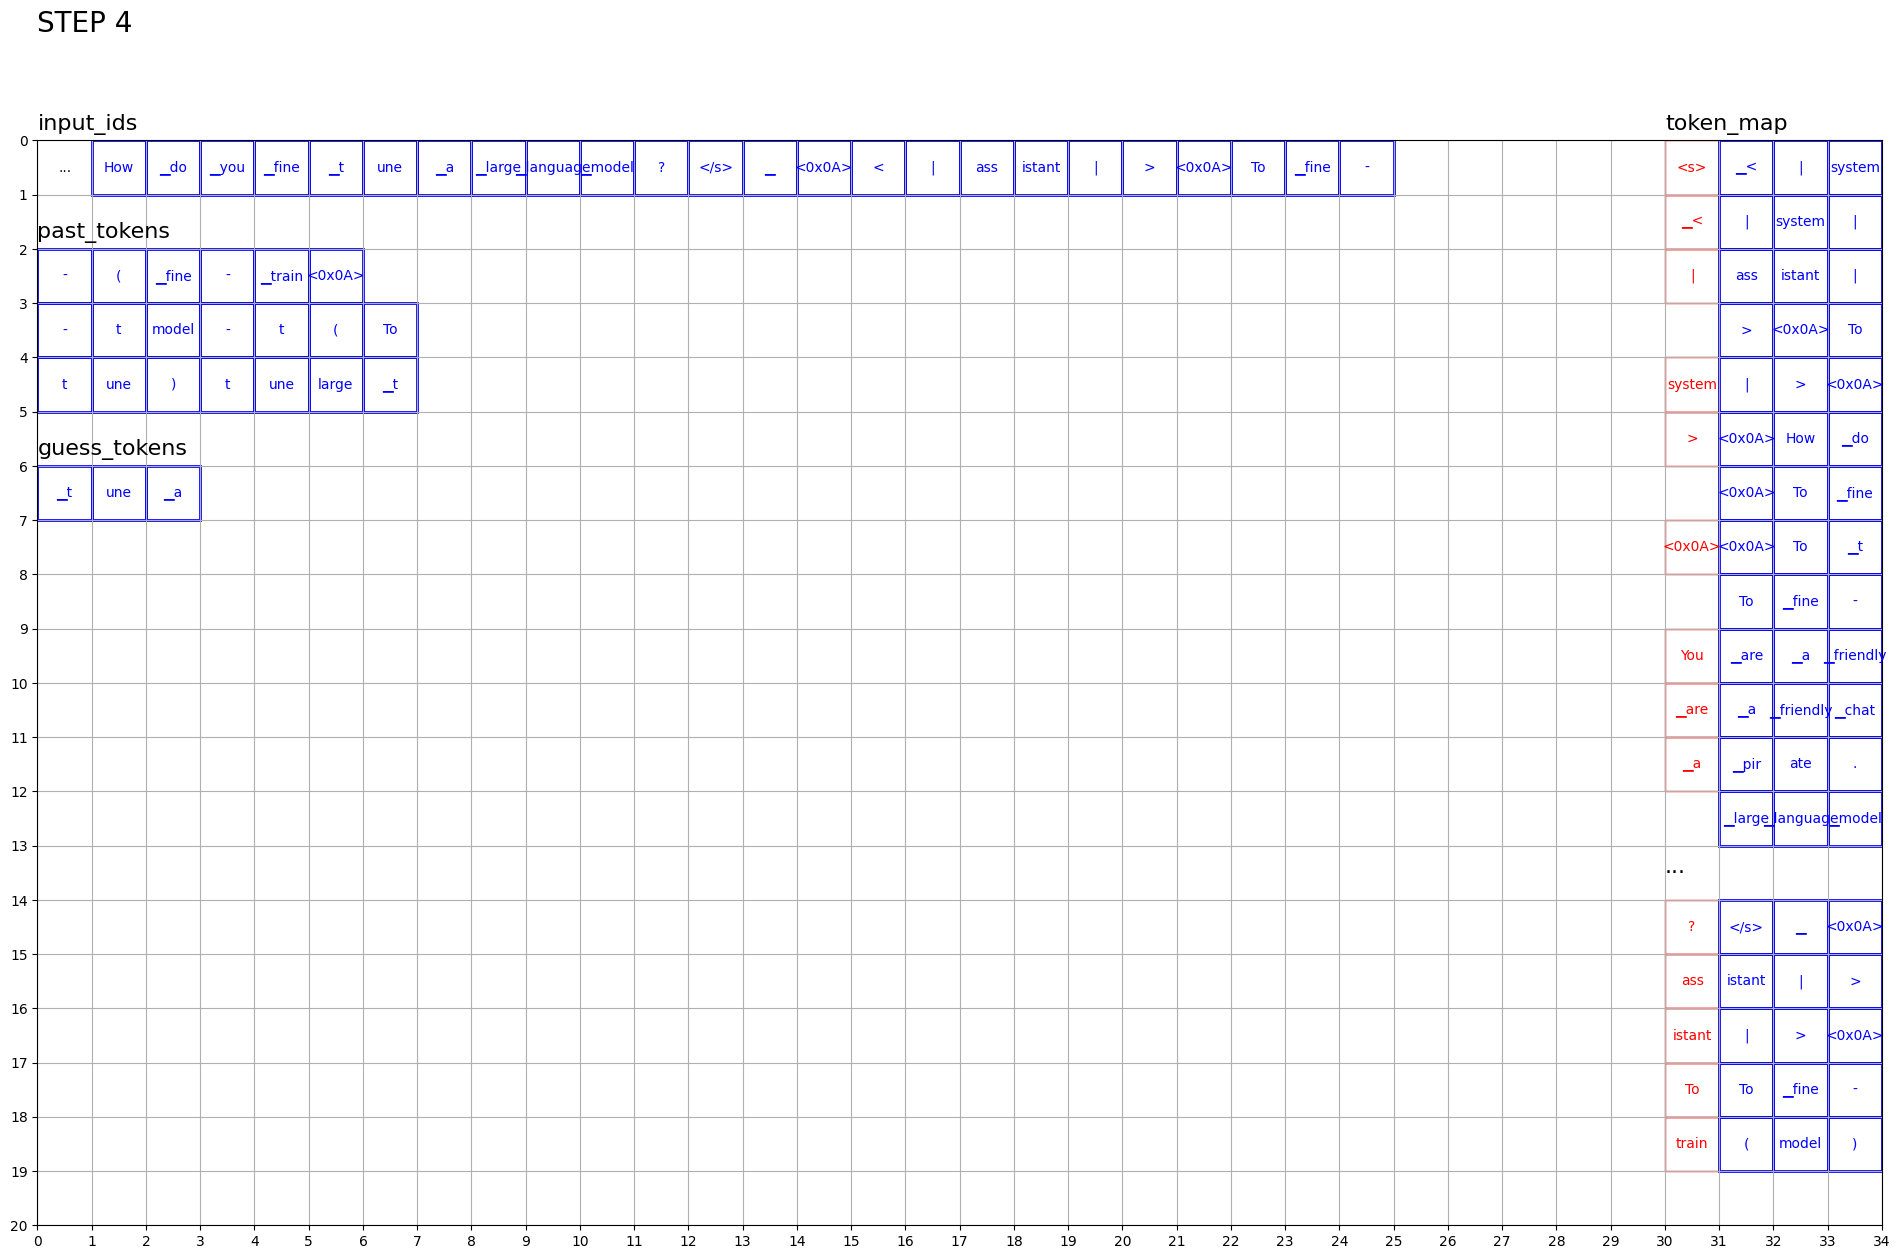

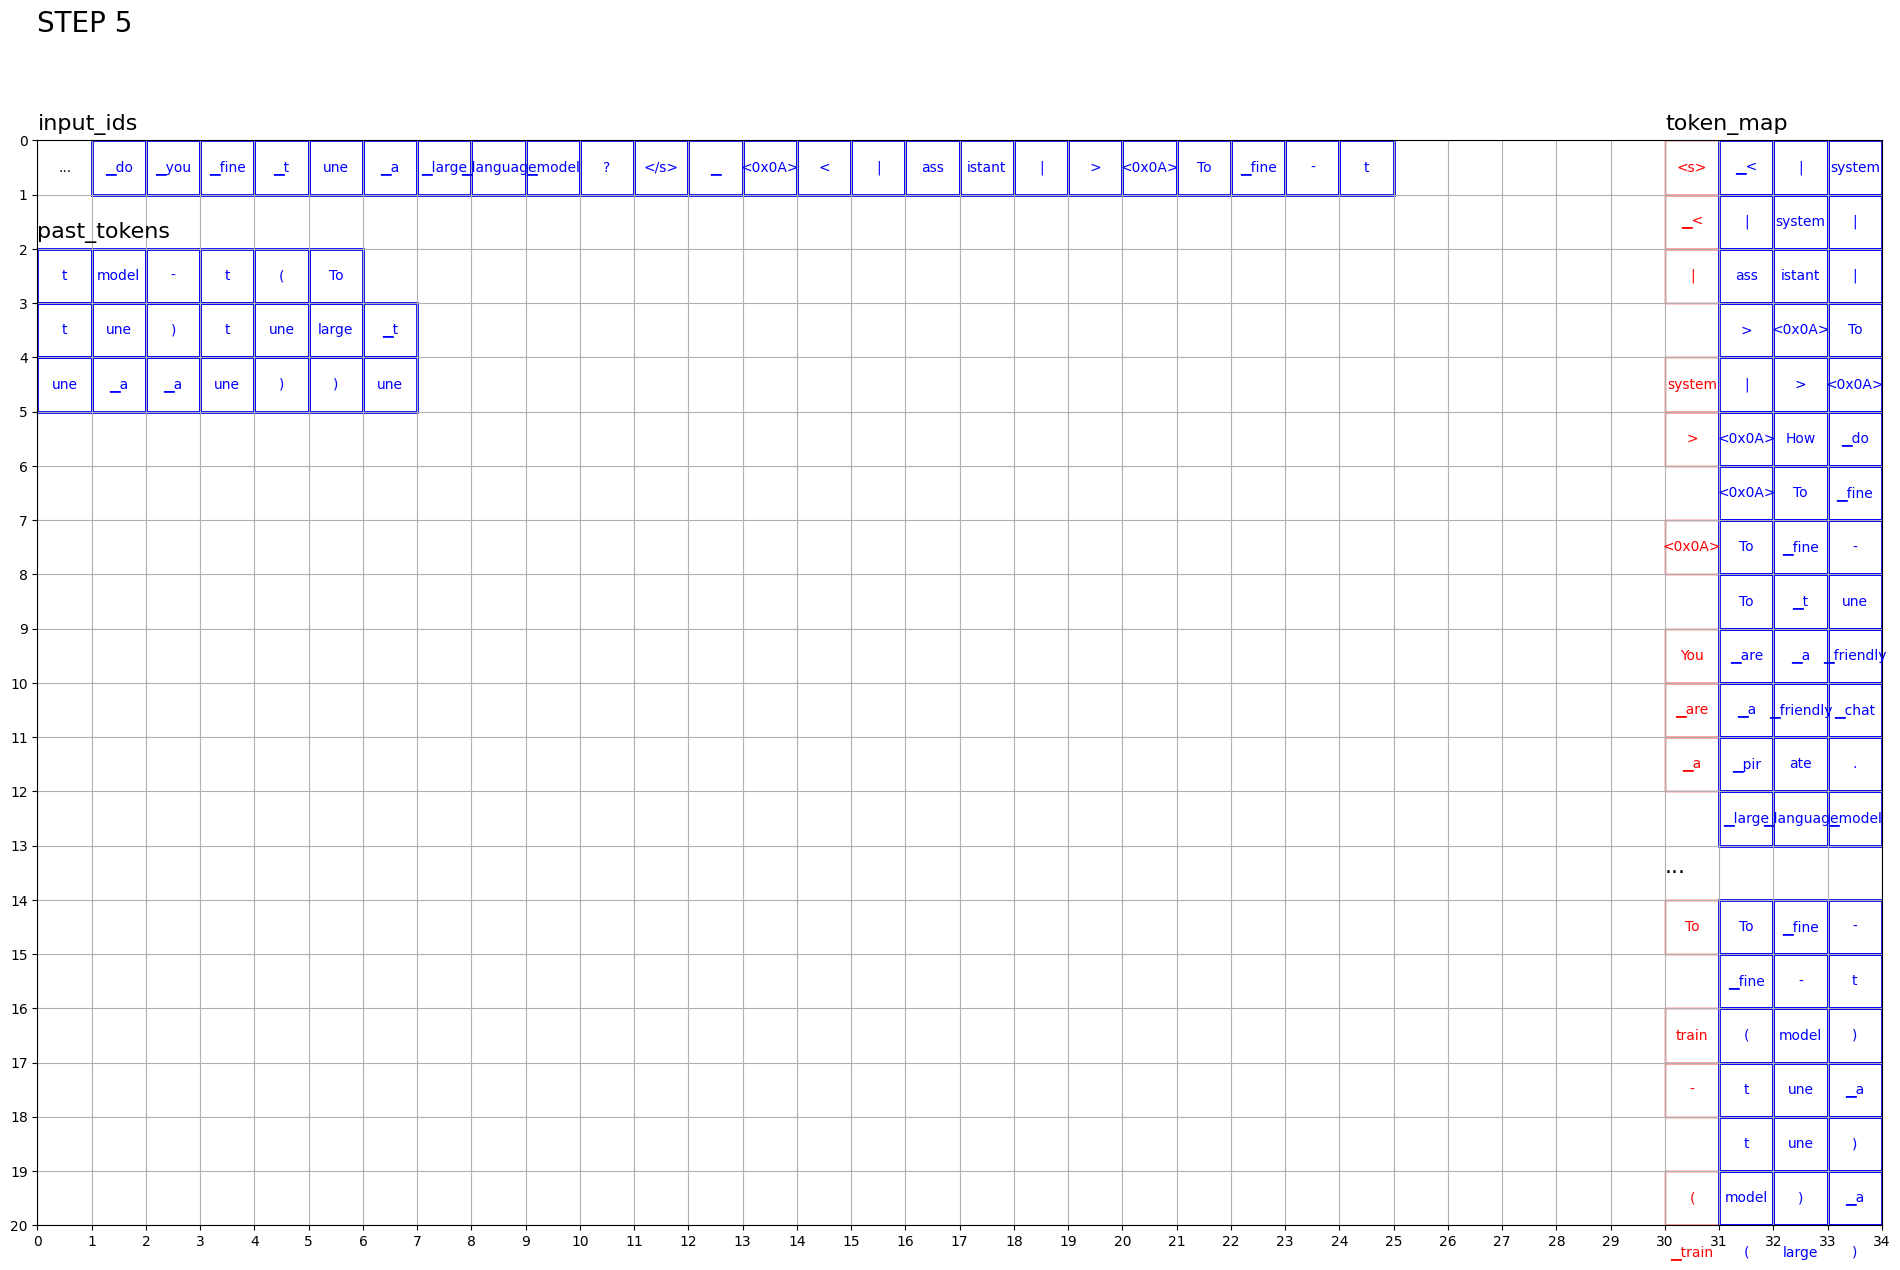

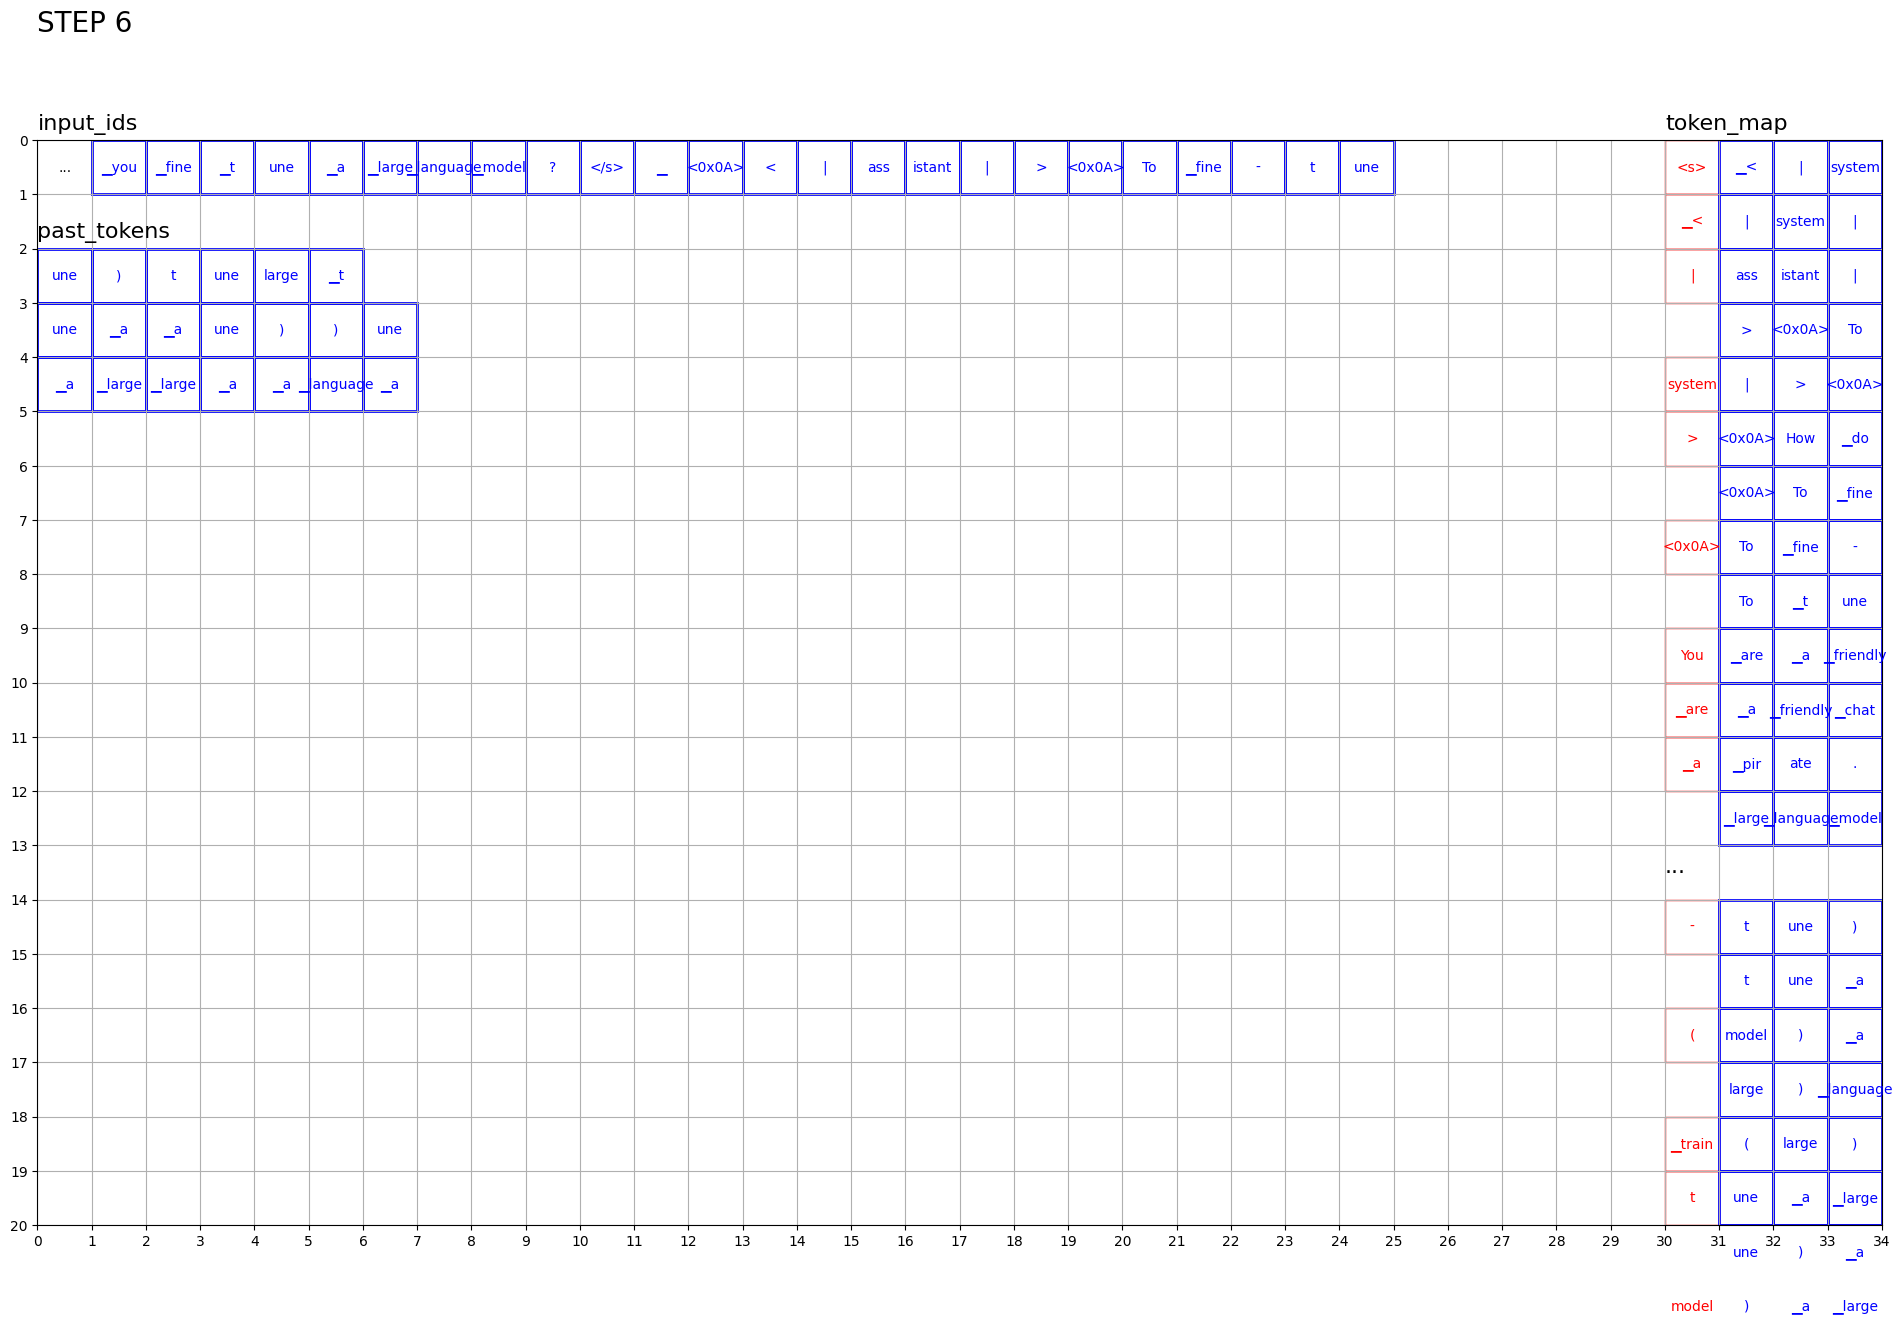

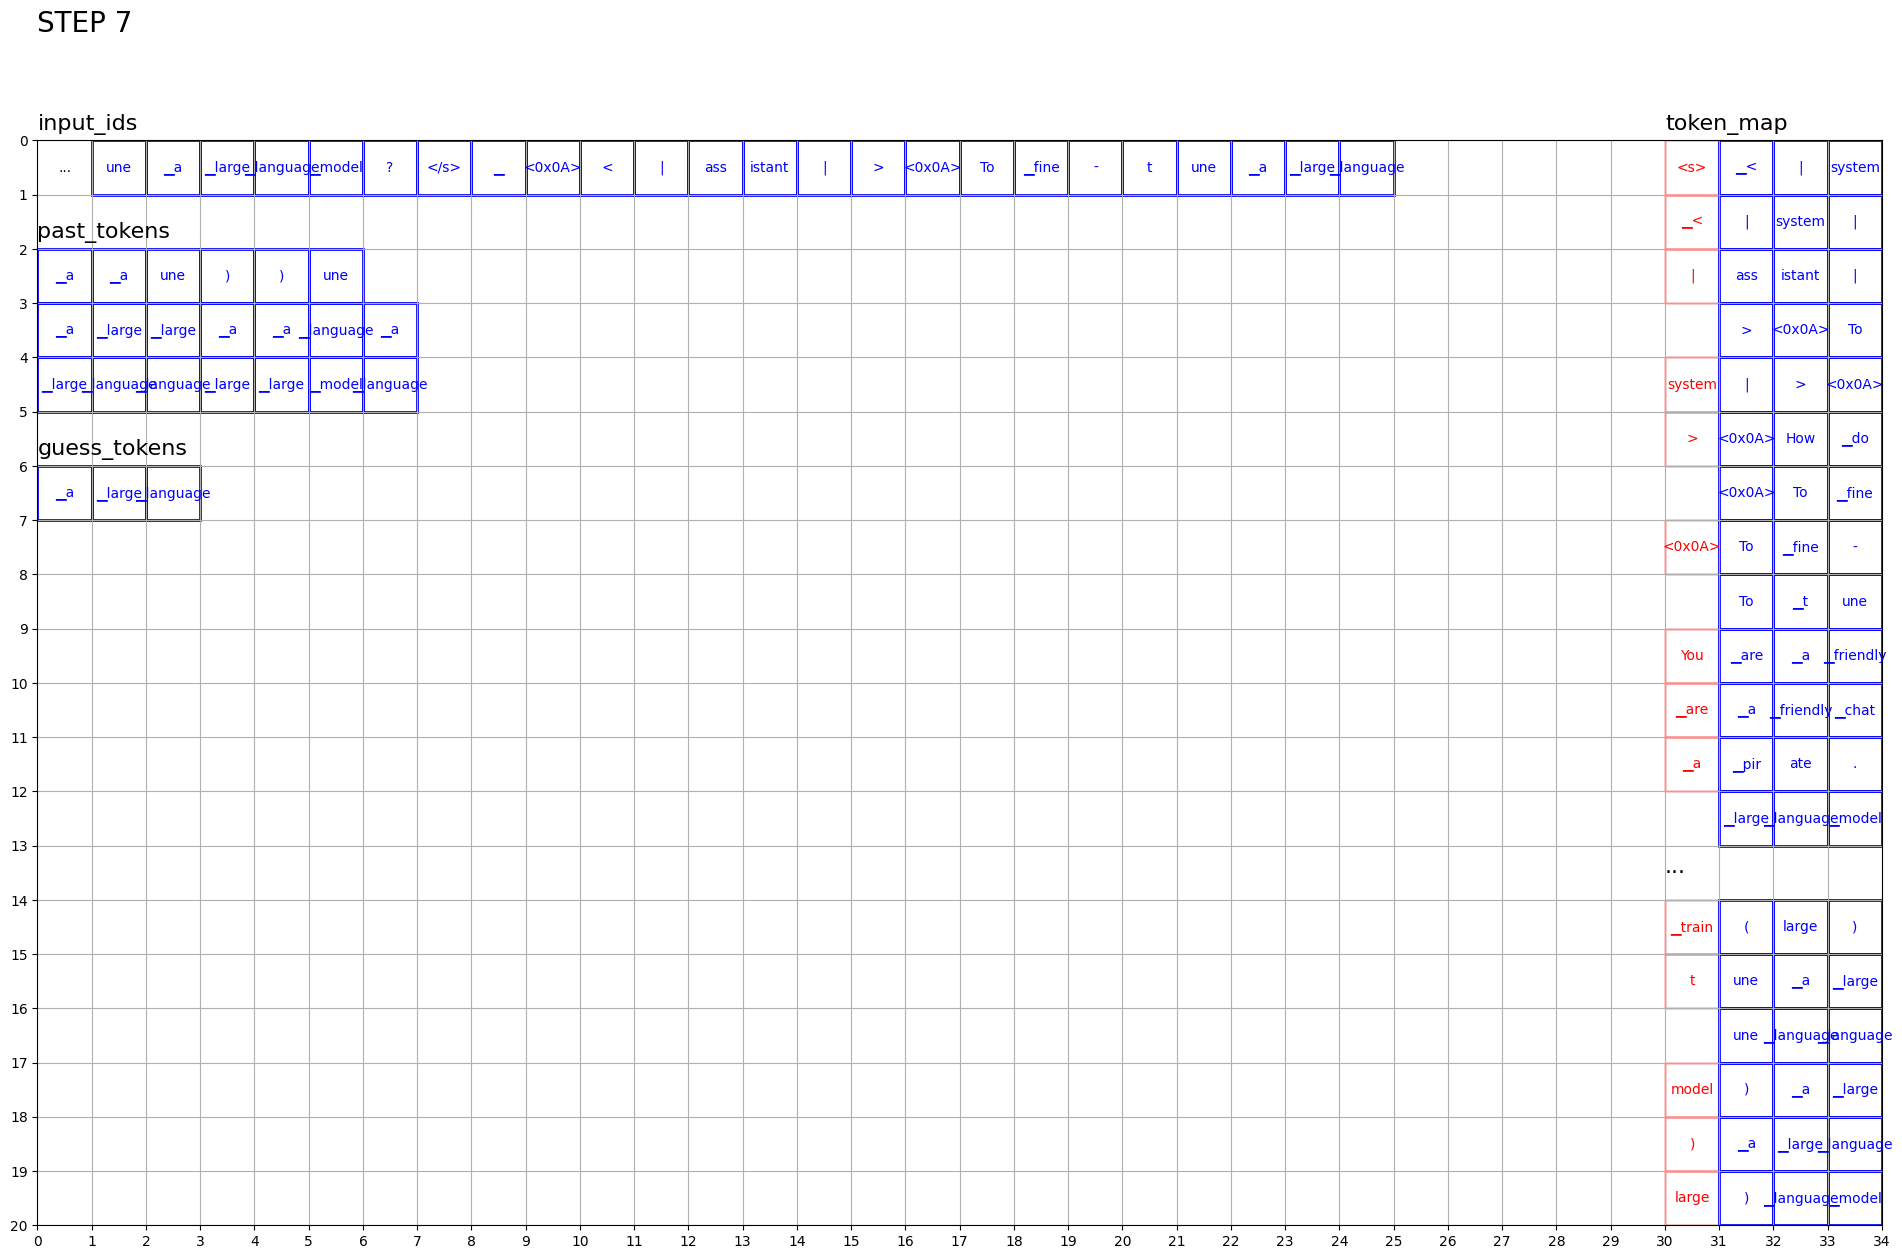

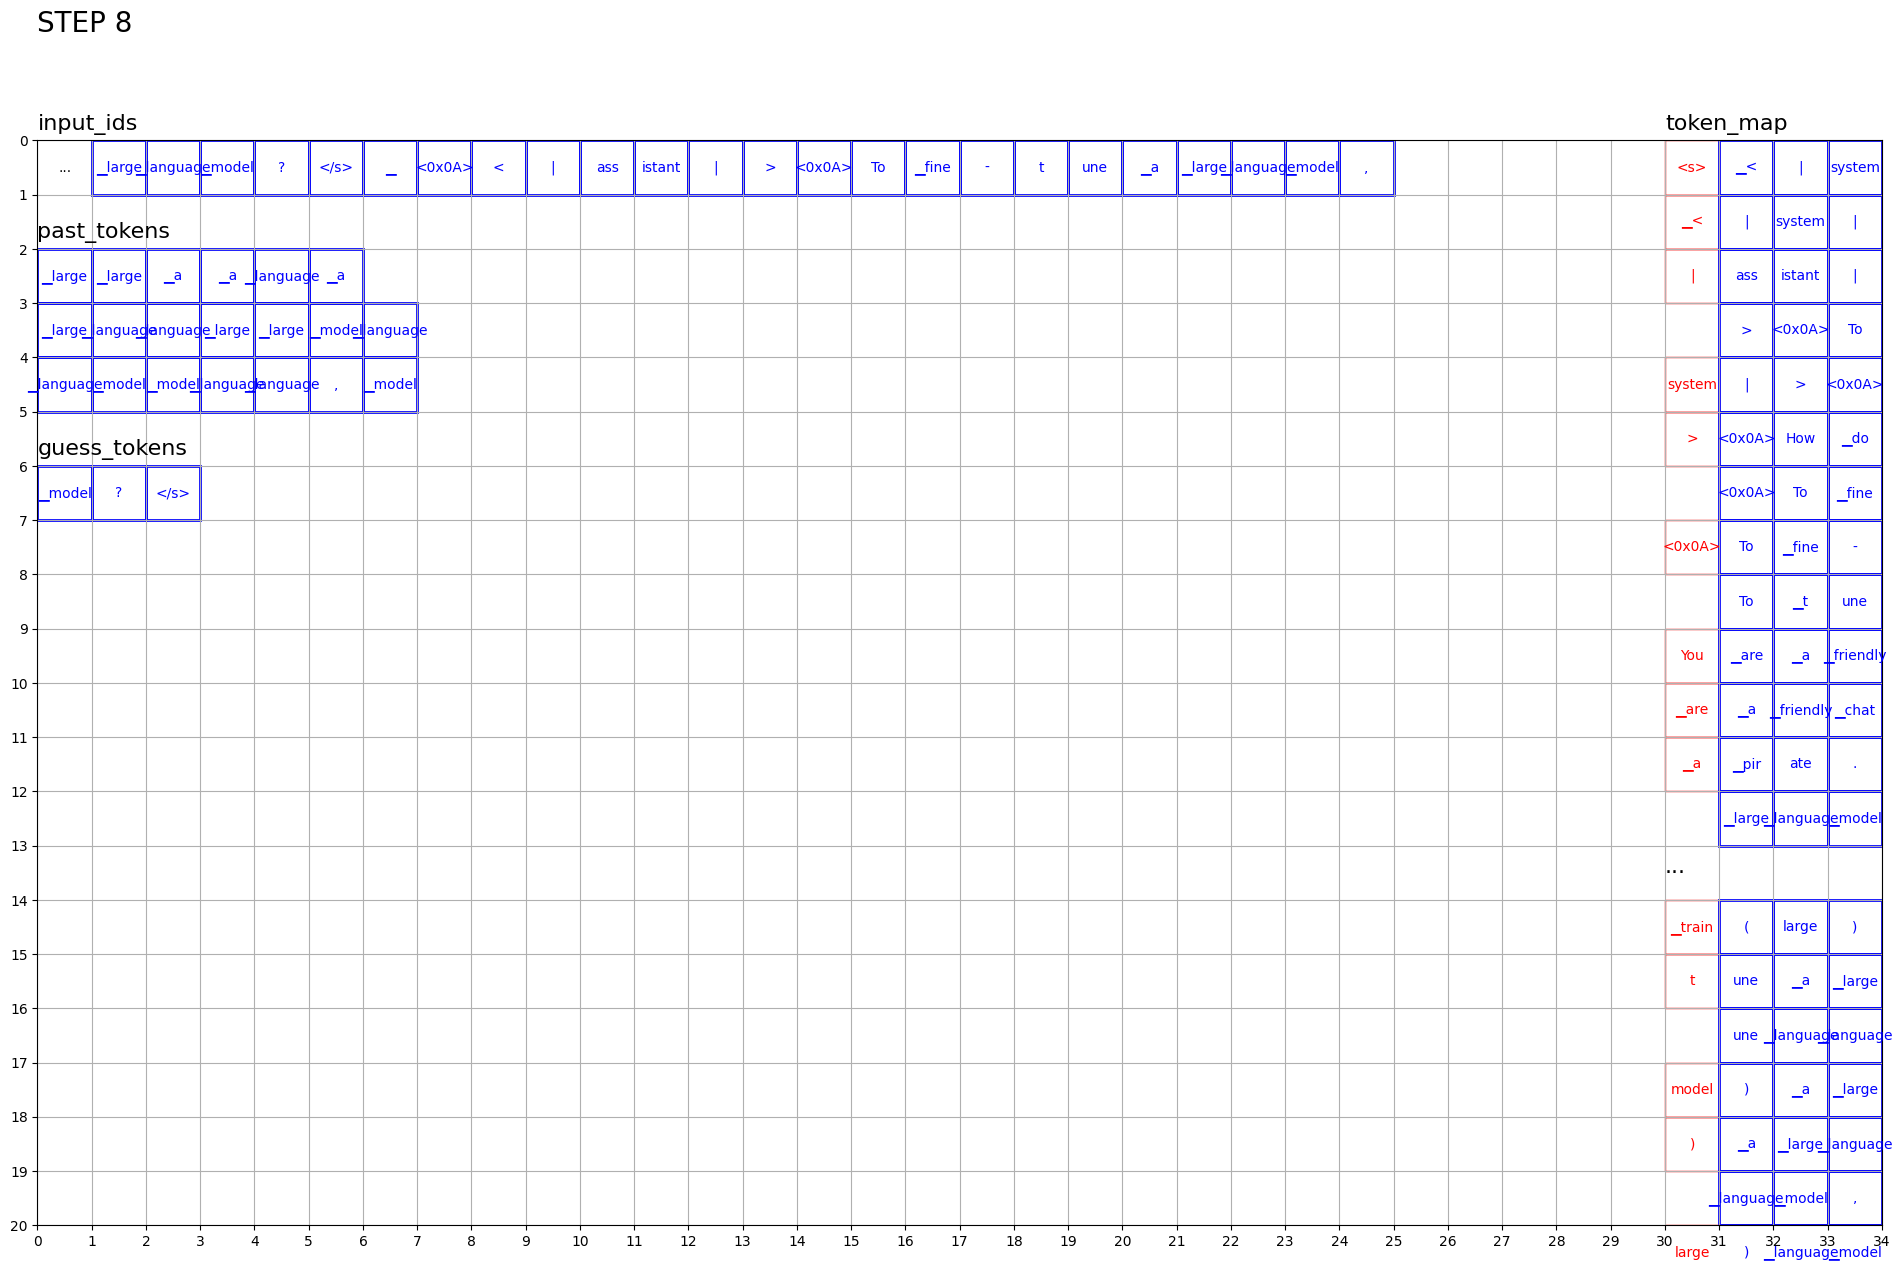

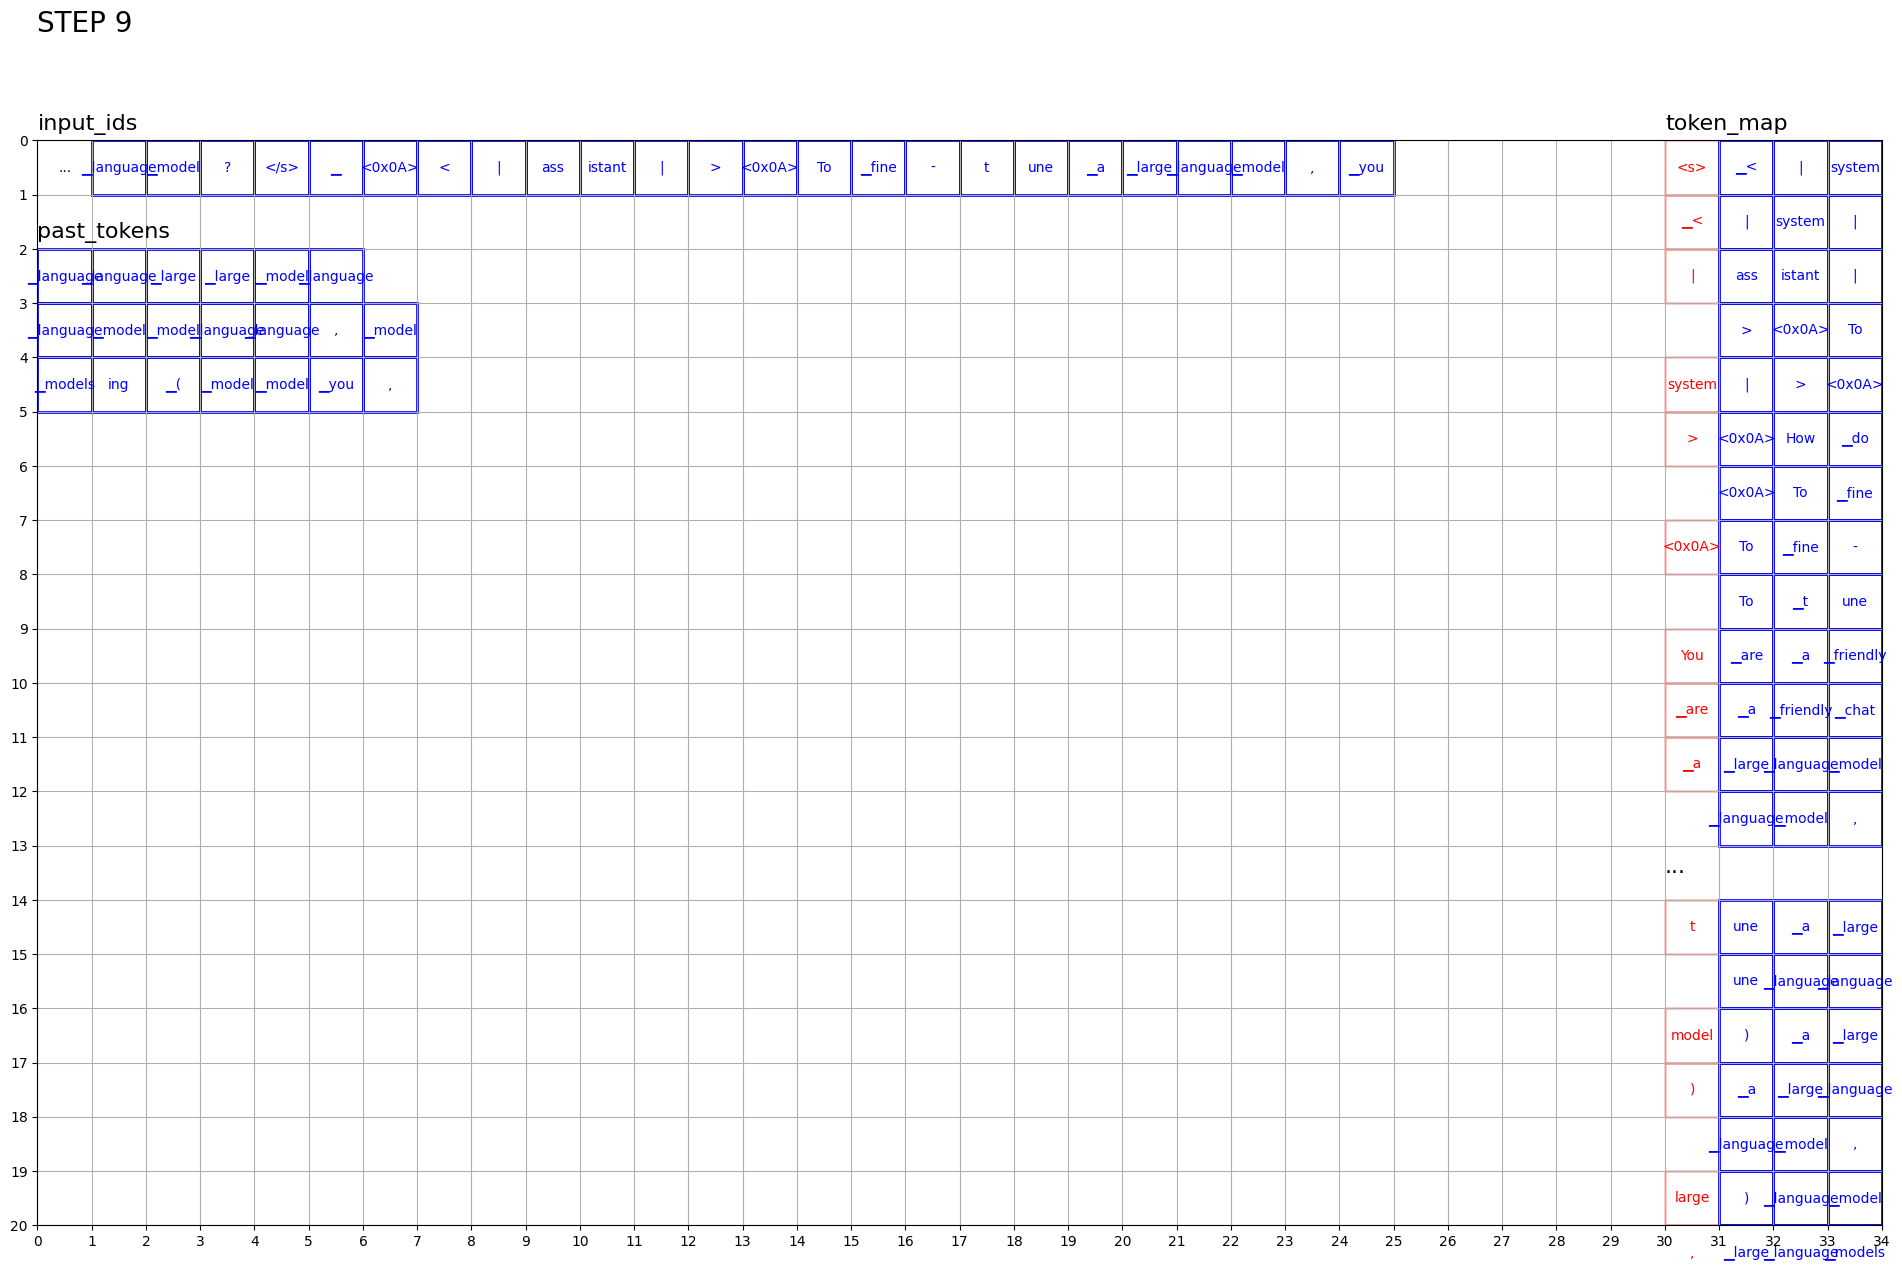

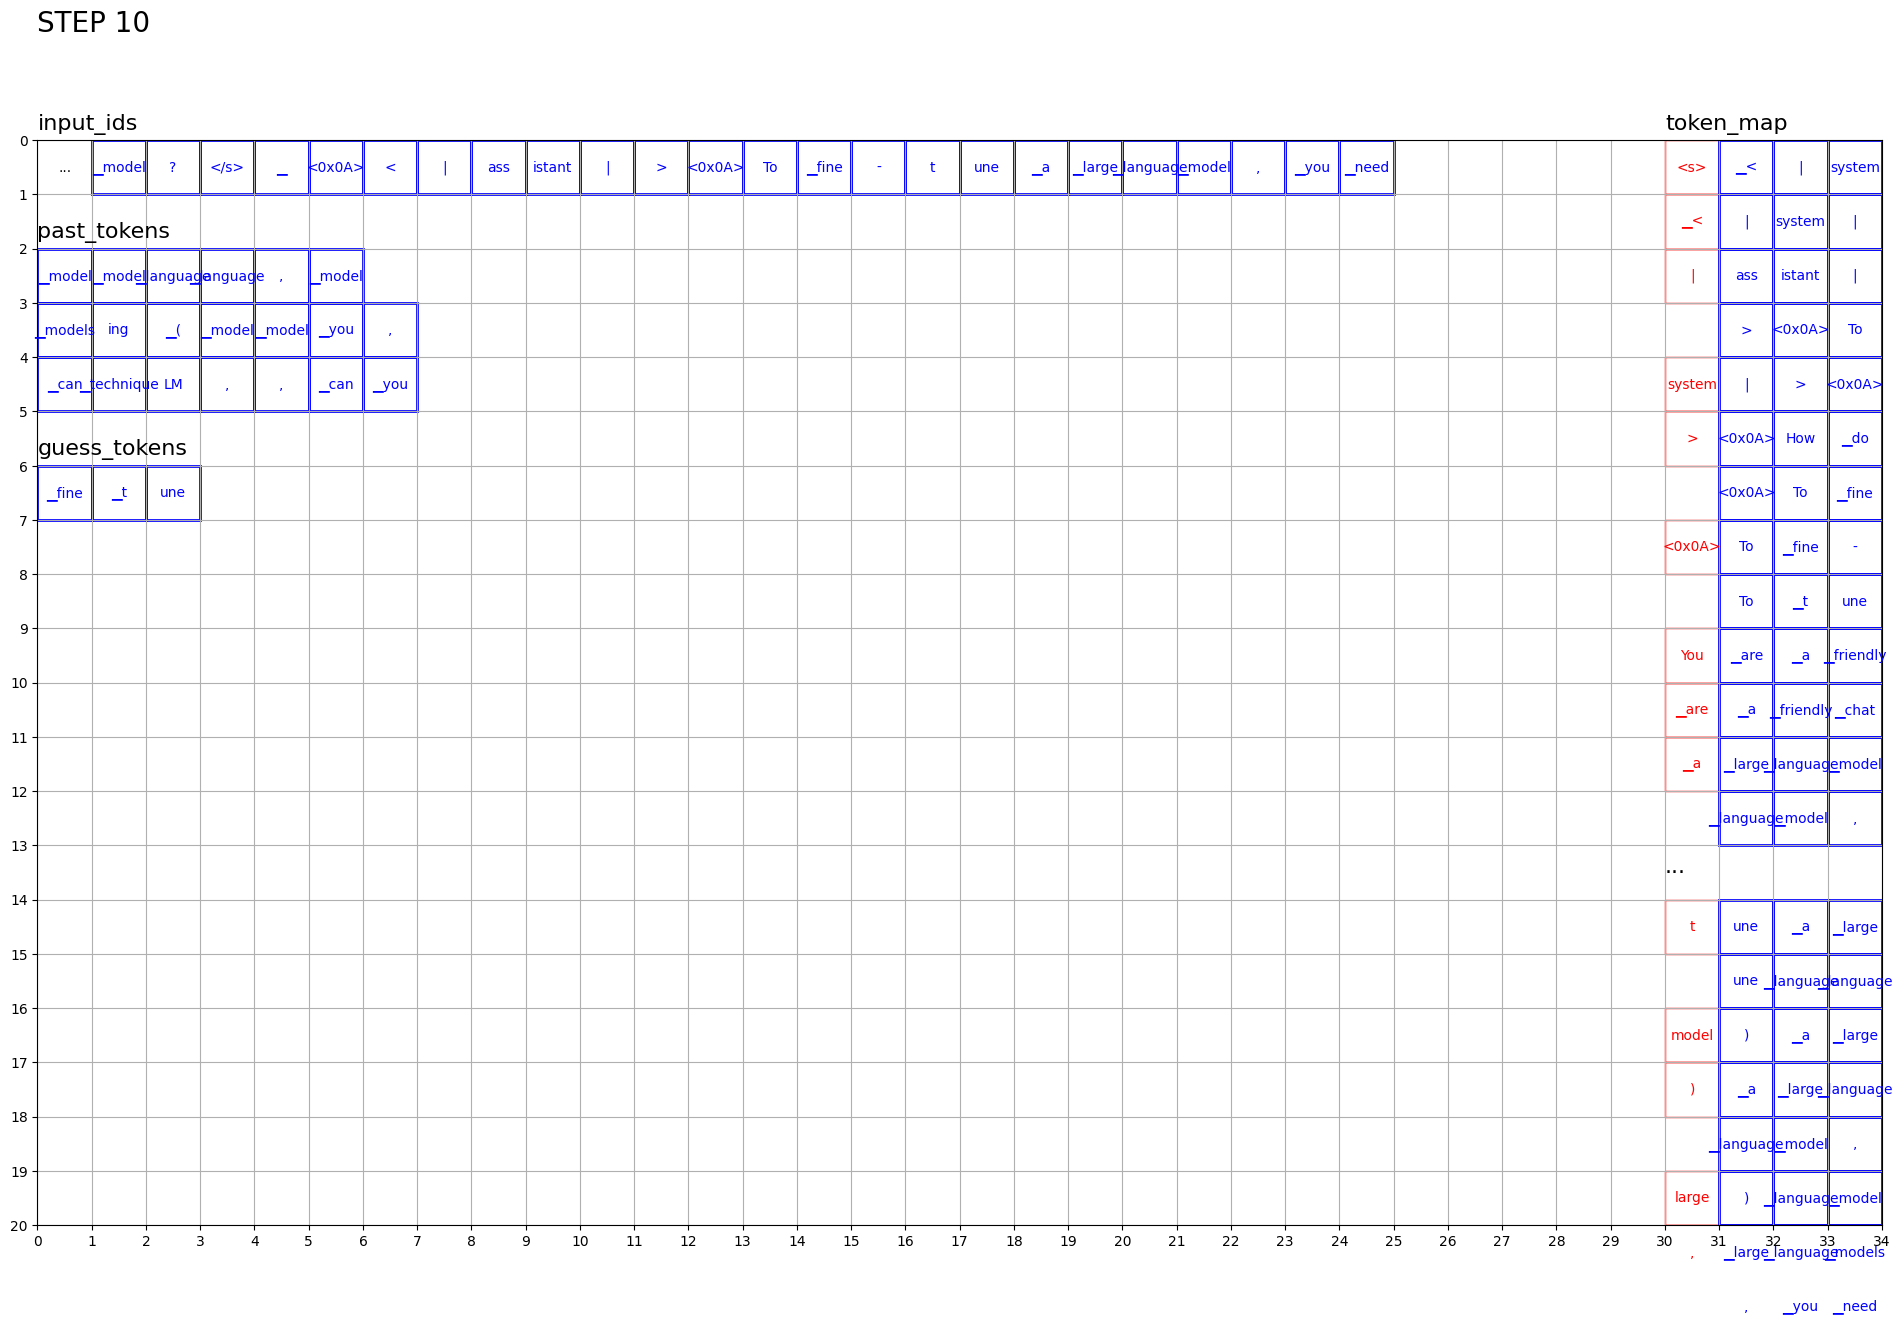

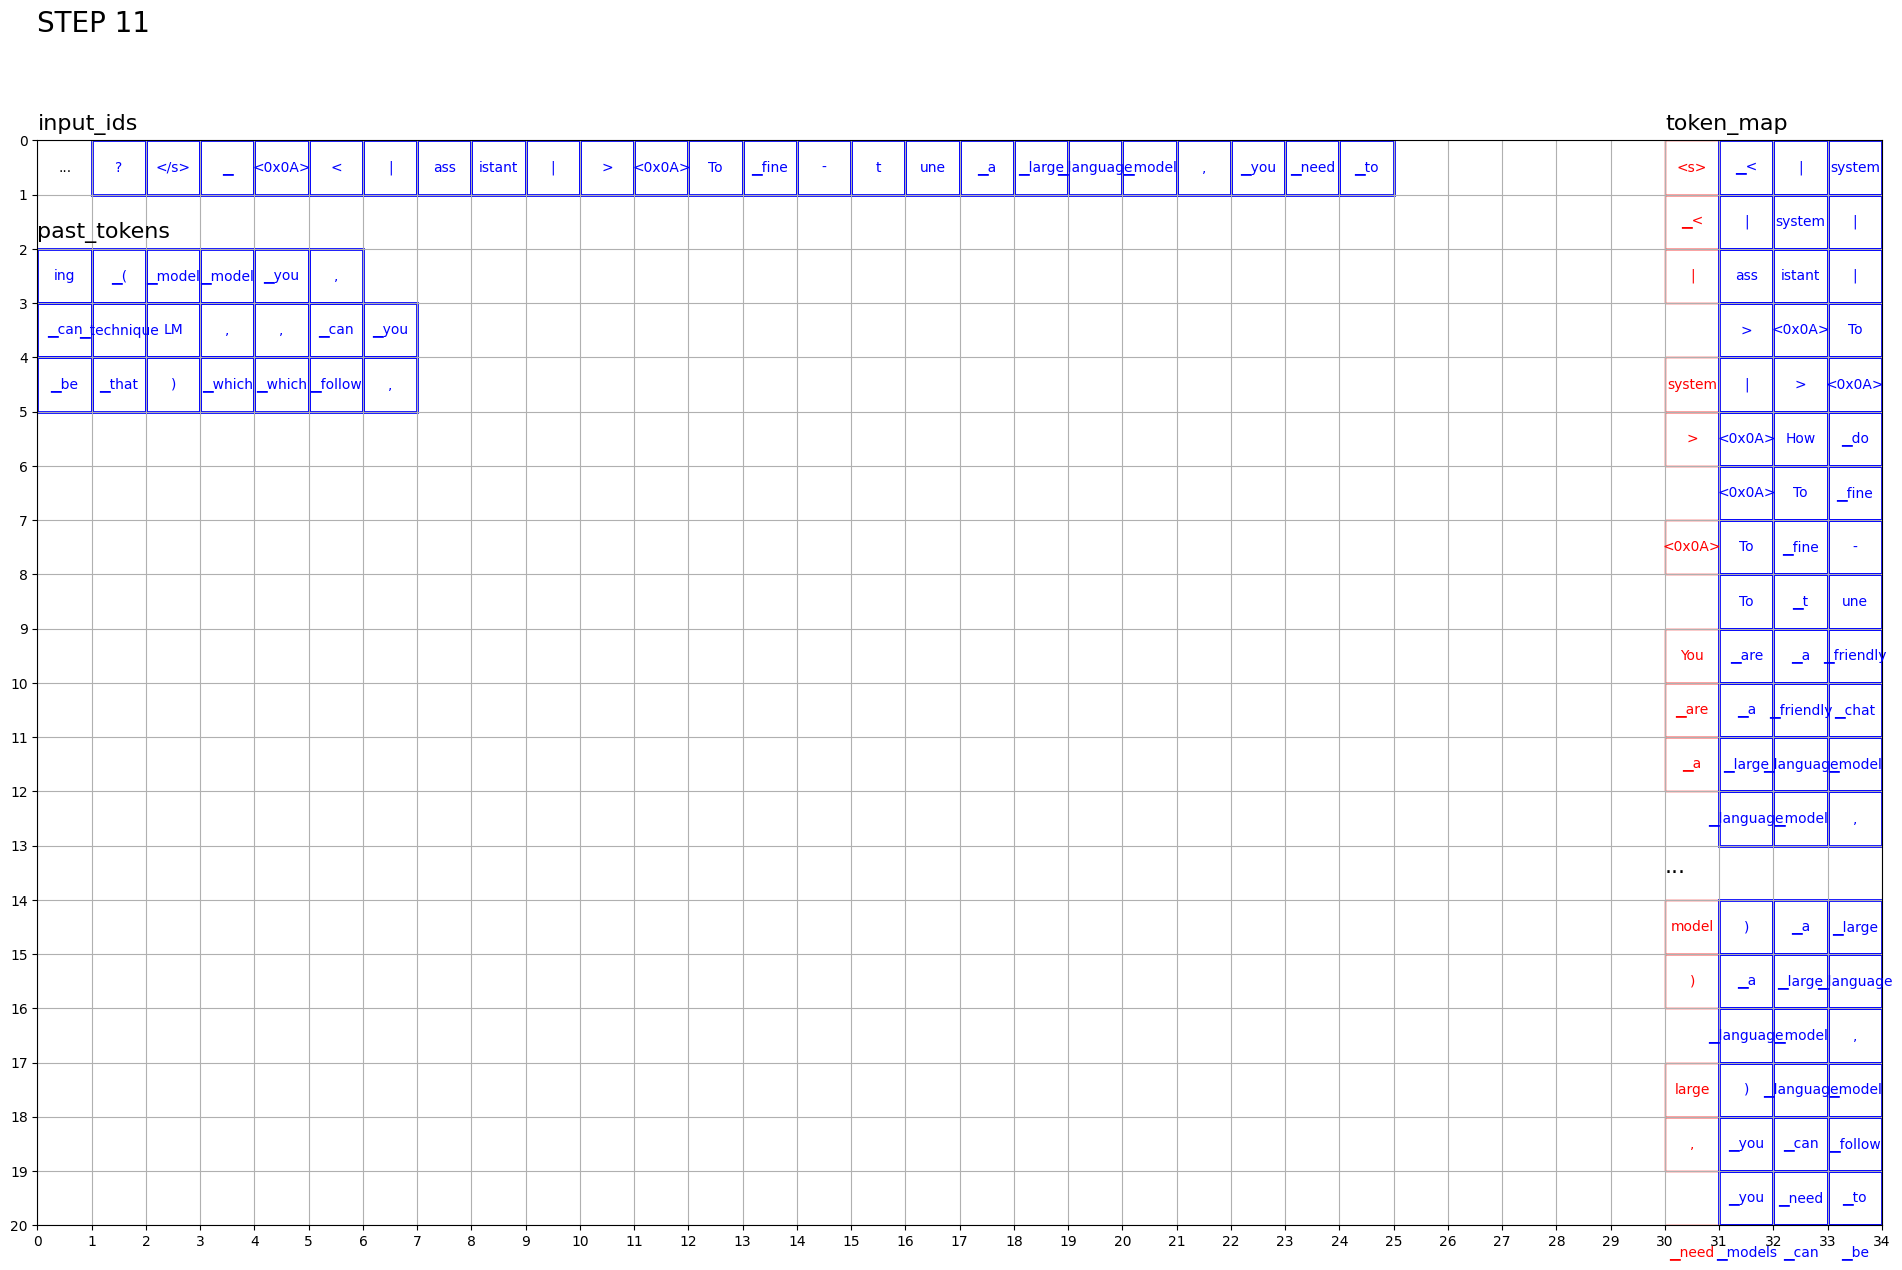

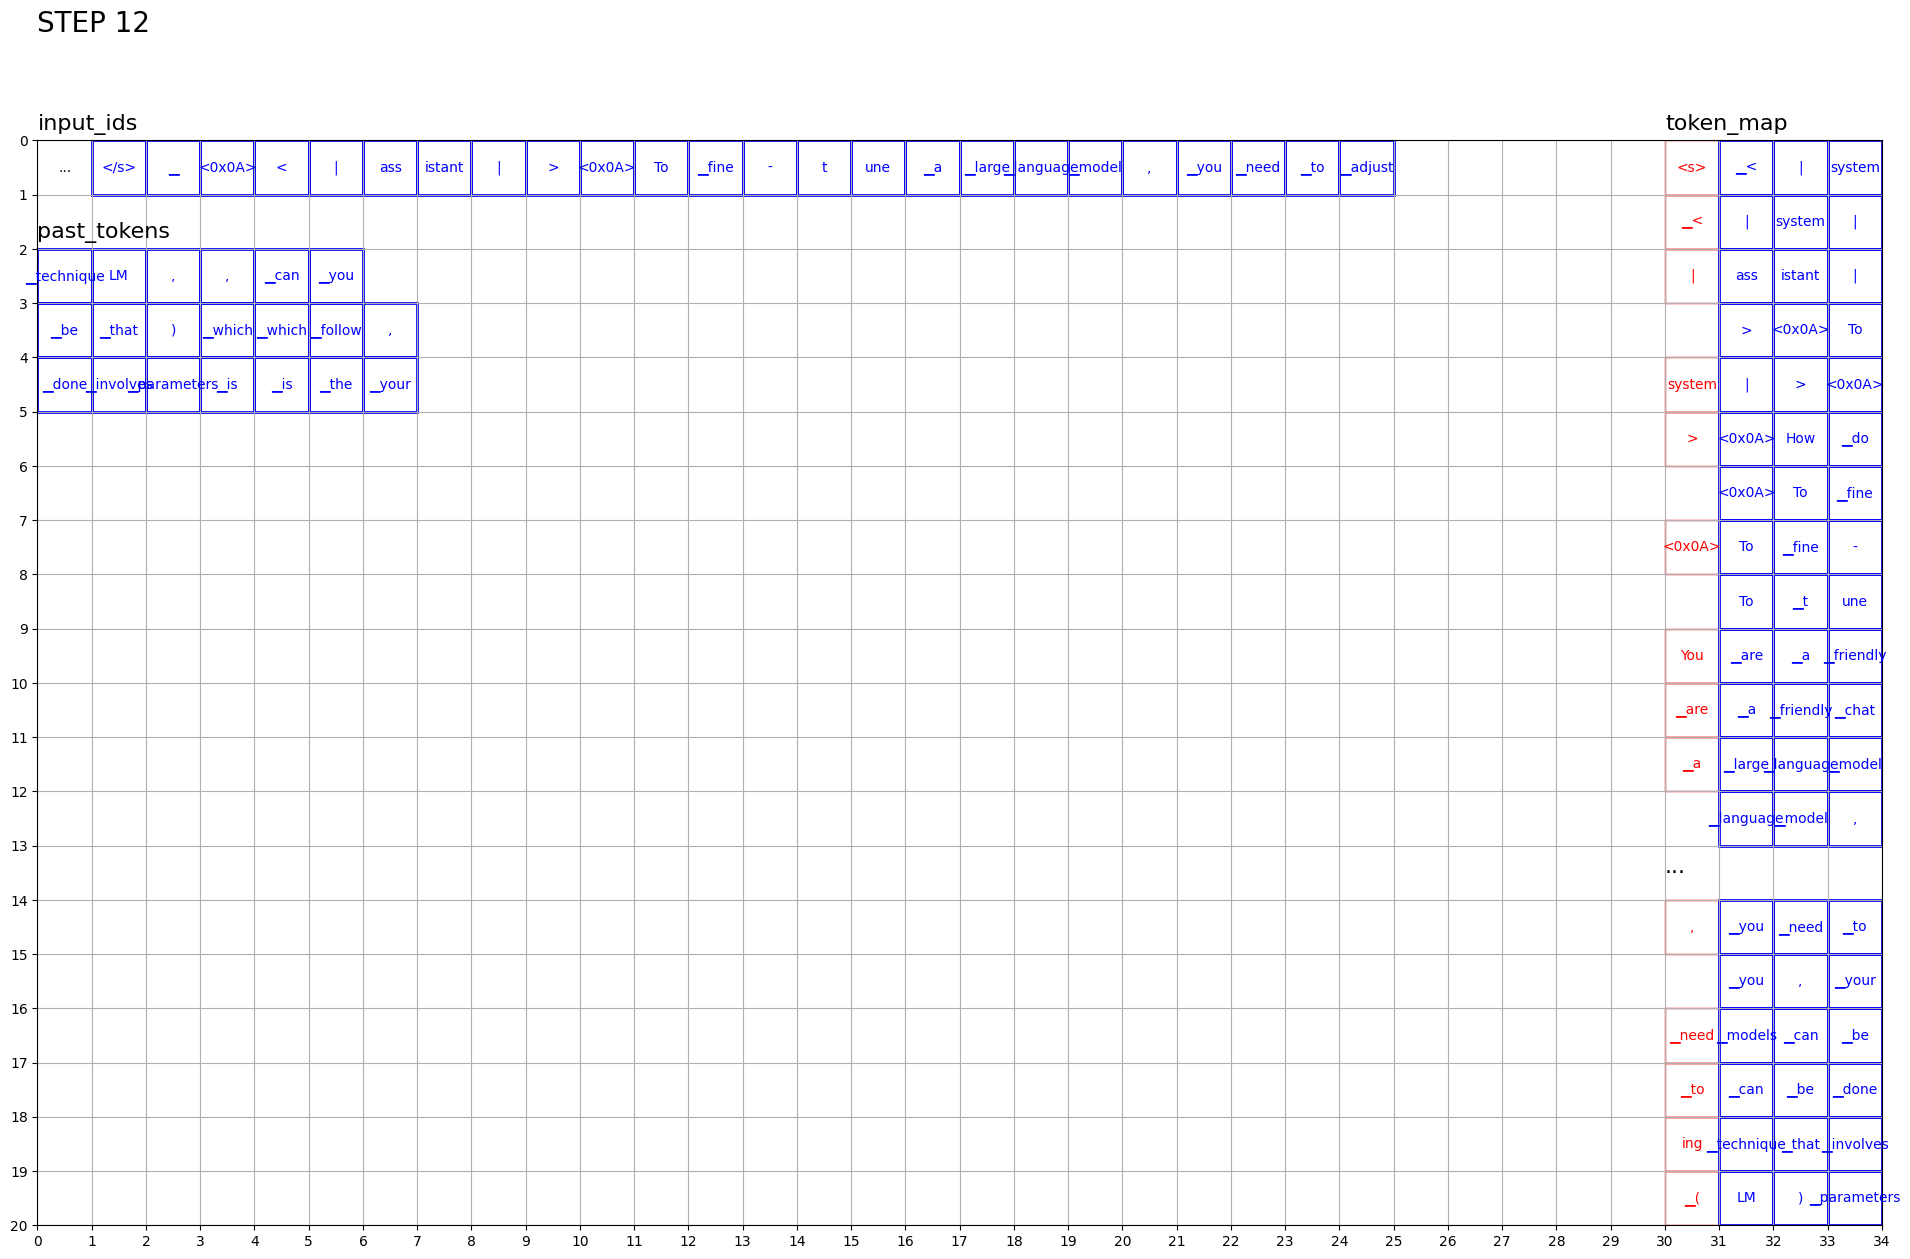

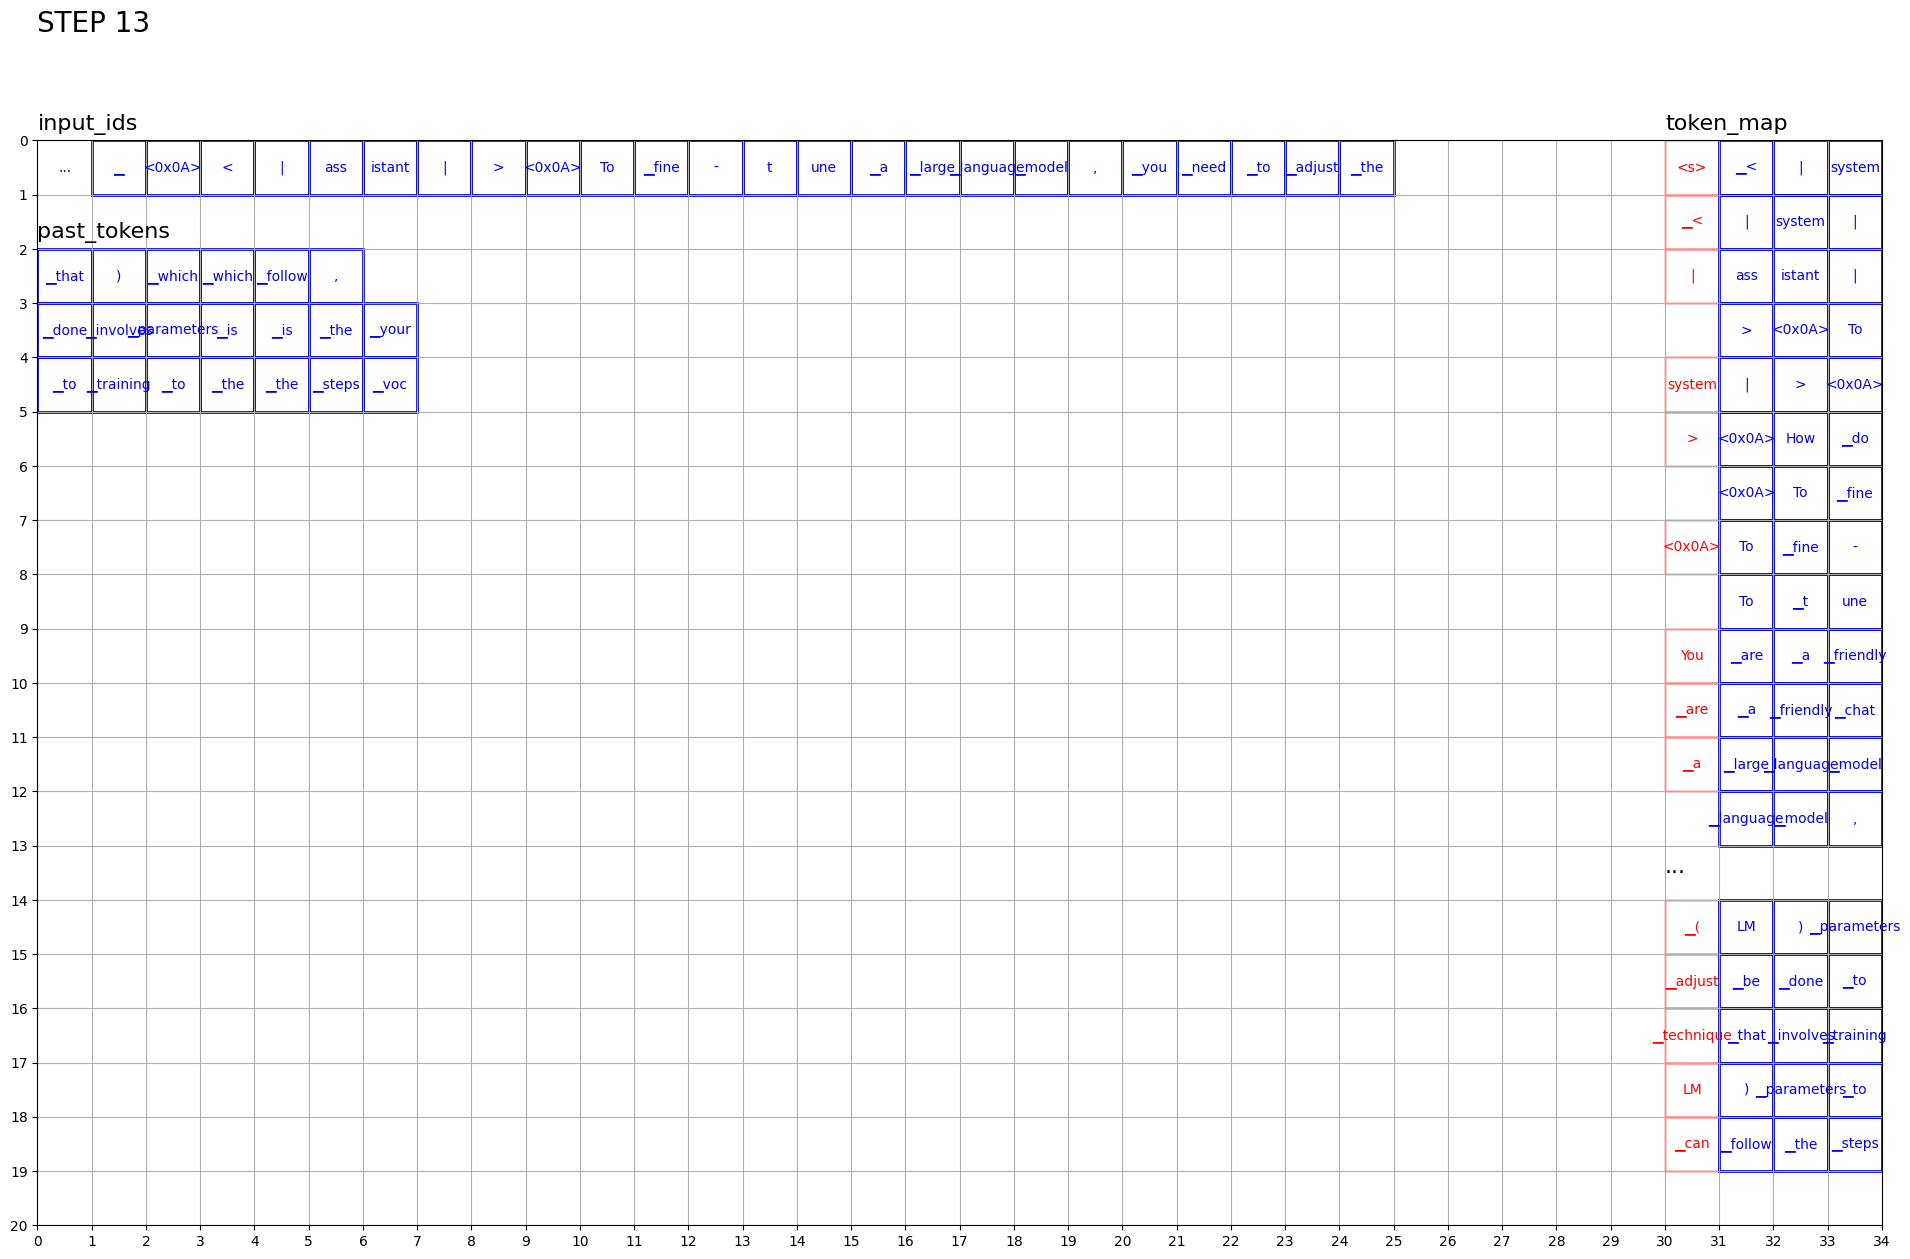

In [114]:
for i in range(14):
	data = pickle.load(open(f'./tests/decoding_{i}.pkl', 'rb'))
	plot_frame(data, i)

In [115]:
import imageio

images = []
for i in range(14):
	images.append(imageio.imread(f'./tests/plot_{i}.png'))

# Set the duration for each frame
durations = [1000] * 13 + [3000]

imageio.mimsave('./tests/plot.gif', images, duration=durations, loop=0)


/tmp/ipykernel_370648/1552344079.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f'./tests/plot_{i}.png'))
